# Bayesian modelling of the latent human influence field in archaeological urban sediments at Koh Ker, Cambodia

This notebook contains all of the code necessary to replicate the analysis and reproduce plots presented in the above named paper. The basic workflow is:

1. Load the data from Excel and CSVs (in ../Data relative to the location of this notebook)
2. Wrangle the data into Pandas dataframes
3. Interpolate depth information for Magnetic Susceptibility (magsus) scans
4. Load and then calibrate radiocarbon dating lab results (involves the use of a function from the ChronoCluster package)
5. Build and run PyMC Bayesian models to reconstruct trench-specific latent-human influence (LHIF) based on magsus and ceramics count data
6. conduct basic MCMC diagnostics (convergence checking)
7. Evaluate the difference between LHIF reconstructions (depth-wise and trench-wise) involving models with and without ceramics data included by looking at posterior difference distributions

Be aware that on a fairly powerful Ubuntu workstation, this notebook takes around 30-40 minutes to run to completion.

## Imports

Here we are just importing the packages used throughout the notebook.

In [2]:
# ---- set PyTensor flags BEFORE importing pymc/pytensor ----
import os
os.environ["PYTENSOR_FLAGS"] = "optimizer_excluding=inplace,exception_verbosity=high,mode=NUMBA"

# data science and other
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import arviz as az
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import math

# Bayes
import pymc as pm
import pytensor
import pytensor.tensor as pt

# global settings
rng = np.random.default_rng(1983)
seed = 1983
nchains = 4

# Display BP ages as positive labels while leaving signed plotting data unchanged.
bp_age_formatter = FuncFormatter(lambda x, pos: f"{abs(x):.0f}")

## Helpers

We create some helper functions below for wrangling magsus readings from across a number of separate CSVs and then combining these data with trench specific depths (from an Excel workbook).

In [3]:
# Function to read the mapping from Excel
def read_mapping_from_excel(file_path):
    # Read the Excel file, assuming the mapping is in the first sheet
    mapping_df = pd.read_excel(file_path, sheet_name=0)
    
    # Create a dictionary mapping MagSusRecord to Trench
    record_to_trench_map = dict(zip(mapping_df['magsus_rec_id'], mapping_df['trench']))
    
    return record_to_trench_map

# Function to process a single CSV file
def process_csv(file_path, record_id, record_to_trench_map):
    # Read the CSV file, skipping first two and last three lines
    data = pd.read_csv(file_path, skiprows=3, skipfooter=3, engine='python')
    
    # Extract relevant columns
    data = data.iloc[:, [0, 1]]  # Columns: scan_idx and susceptibility
    data.columns = ['scan_idx', 'susceptibility']
    
    # Add Record_ID and Trench_ID
    data['record_id'] = record_id
    data['trench_id'] = record_to_trench_map.get(record_id, 'Unknown')
    
    return data[['record_id', 'trench_id', 'scan_idx', 'susceptibility']]

# Read the mapping from the Excel file
excel_path = '../Data/MagSusMap.xlsx'
record_to_trench_map = read_mapping_from_excel(excel_path)

# List of files and corresponding record IDs
files = []

# Base path for the data folder
base_path = '../Data/kt20_0467/'

# Loop over each row in the mapping DataFrame
for record_number in record_to_trench_map.keys():
    folder_name = f"{record_number}"     # Create the folder name from the record number
    file_name = f"record_scanner_10khz_{record_number}.csv"  # Create the CSV file name
    file_path = f"{base_path}{folder_name}/{file_name}"  # Construct the full file path
    
    # Append the file path and record number as a tuple to the list
    files.append((file_path, record_number))

# Process all files and concatenate the results
magsus = pd.concat([process_csv(file, record_id, record_to_trench_map) for file, record_id in files])

# Display the combined DataFrame
print(magsus)


    record_id  trench_id  scan_idx  susceptibility
0           8          1         1          0.0000
1           8          1         2          0.0055
2           8          1         3          0.0180
3           8          1         4          0.0413
4           8          1         5          0.0415
..        ...        ...       ...             ...
43         64          8        44          0.0174
44         64          8        45          0.0091
45         64          8        46          0.0442
46         64          8        47          0.0391
47         64          8        48          0.0252

[1737 rows x 4 columns]


In [4]:
# depth data

trench_map_depth = pd.read_excel(excel_path)

# Create a dictionary with keys as (trench_id, record_id) and values as MaxDepth_cm
trench_depths = trench_map_depth.set_index(['trench', 'magsus_rec_id'])['max_dbs_cm'].to_dict()

# this function produces depth sequences assuming a linear relationship between 
# scan index (essentially time-series index) and physical depth along the 
# profile wall

def add_depth_column(df, trench_depths):
    """
    Adds a depth column to the DataFrame based on the scan index and the given top/bottom depths for each trench.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing magnetic susceptibility scan data.
    trench_depths (dict): Dictionary with (trench_id, record_id) as keys and MaxDepth_cm as values.
    
    Returns:
    pd.DataFrame: DataFrame with an additional column 'depth' representing the calculated depth for each scan.
    """
    def calculate_depth(row):
        # Get the bottom depth for the current trench and record
        max_depth = trench_depths[(row['trench_id'], row['record_id'])]
        
        # Assuming top_depth is 0 for all trenches
        top_depth = 0.0
        
        # Calculate the total number of scans in this trench's record
        max_scan_idx = df[(df['trench_id'] == row['trench_id']) & 
                          (df['record_id'] == row['record_id'])]['scan_idx'].max()
        
        # Calculate depth increment per scan index
        depth_increment = (max_depth - top_depth) / (max_scan_idx - 1)
        
        # Calculate the depth for the current scan index
        depth = top_depth + (row['scan_idx'] - 1) * depth_increment
        
        return depth

    # Apply the calculate_depth function to each row and add the resulting column to the dataframe
    df['depth'] = df.apply(calculate_depth, axis=1)
    
    return df

magsus = add_depth_column(magsus, trench_depths)
magsus.to_csv('../Output/magsus_scans.csv', index=False)
magsus

,record_id,trench_id,scan_idx,susceptibility,depth
0,8,1,1,0.0000,0.000000
1,8,1,2,0.0055,1.774194
2,8,1,3,0.0180,3.548387
3,8,1,4,0.0413,5.322581
4,8,1,5,0.0415,7.096774
...,...,...,...,...,...
43,64,8,44,0.0174,91.489362
44,64,8,45,0.0091,93.617021
45,64,8,46,0.0442,95.744681
46,64,8,47,0.0391,97.872340


## Normalization

Normalizing the magsus readings make model fitting easier and focuses on relative deviations across all of the replicates rather than using raw values which are harder to interpret.

In [5]:
# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Sort the magsus DataFrame by trench_id and record_id
magsus = magsus.sort_values(by=['trench_id', 'record_id', 'scan_idx'])


## Radiocarbon Data

We need to load in the radiocarbon measurement data provide by the dating lab and then correlate these measurements with the trench specific depth information (the specific trench and depth from which each radiocarbon sample was drawn). Additionally, the samples are of two distinct kinds: 1) charcoal and 2) bulk sediment. So, we create a dataframe that contains all the relevant information for these samples including provenience and material type.

In [6]:
# Load the CSV file into a Pandas DataFrame
file_path = '../Data/kkpp24_c14.csv'
c14_data = pd.read_csv(file_path)

# Extract 'trench' and 'depth' from 'sample_id' and convert them to integers
import re

c14_data['trench'] = c14_data['sample_id'].apply(lambda x: int(x.split('_')[1]))  # Extract trench as an integer
c14_data['depth'] = c14_data['sample_id'].apply(lambda x: int(re.sub(r'\D', '', x.split('_')[2])))  # Remove non-numeric characters from depth


# Step 3: Display the updated DataFrame
print(c14_data.head())


   ugams     sample_id  material  d13C_ppm  ybp_14C  error_14C    pMC  \
0  73631   KKPP24_1_10  sediment    -24.83     1120       20.0  86.95   
1  73632   KKPP24_1_50  sediment    -26.35     4340       25.0  58.27   
2  73633  KKPP24_1_100  sediment    -26.63     3090       20.0  68.10   
3  73634   KKPP24_2_10  sediment    -23.75     1530       20.0  82.67   
4  73635   KKPP24_2_40  sediment    -27.13     4130       20.0  59.78   

   error_pmc  trench  depth  
0       0.21       1     10  
1       0.17       1     50  
2       0.18       1    100  
3       0.21       2     10  
4       0.17       2     40  


## Calibration

At this point, we are calibrating radiocarbon dates. There is no canonical radiocarbon calibration package in conda and so we are using here a package developed for conducting point pattern analyses on data with chronological uncertainty. The package contains a calibration method called 'calrcarbon' and can load the intcal20 curve used to calibrate these specific dates.

**The direction of time**

It is important to note that ChronoCluster (the tool we use for calibration) is iconoclastic and opinionated about the way we represent time in historical and palaeo-data-science. The tradition in much of archaeology has long been that years before present (calibrated or uncalibrated) are represented as increasing positively into the past. At the same time, the more classical BC/AD and BCE/CE calendars generally represent the direction of time as positive numbers in both directions from the canonical temporal datum (either 0 or 1 BC and 1 AD, depending on the attention to historical detail). These inconsistencies are not only confusing, but can lead to unforced errors in computational environments were computers often sort vectors of numbers left-to-right and top-to-bottom increasing. This often results in the need to double check that sorting operations and data wrangling hasn't inadvertently flipped the direction of one or more columns in a time-registered dataset relative to the others. It also often means we need to spend time flipping plotting axes to conform with normative scholarly expectations, which differ across the historical and natural sciences (where nearly ever other discipline expects that time proceeds right-ward into the future on a time-series plot, for instance). 

To avoid this problem, ChronoCluster assumes that time flows in the expected computational way (increasing left-to-right and top-to-bottom). It also asserts and assumes that these various calendars really differ only in terms of their datum and explicitly requires the datum to be stated. So, the 'before present' calendar (unless otherwise specified) has a datum of 1950 (BP1950) and the common era calendar has a datum of 0. In both cases, negative numbers reflect increasing age to the left of the given datum and positive numbers reflect progressing time to the right of the datum. As a result, the only difference among these calendar systems is where the datum lies and this makes comparison and translation more consistent while at the same time reducing the potential for column flipping and other unforced errors.

In order to conform to scholarly expectations, however, we have simply removed the sign from the before present ages in the plots only. In the background, the sign remains.

In [7]:
# Import the full module to ensure initialization code (e.g., intcal20) runs
import chronocluster.distributions

# Import the specific calibration class
from chronocluster.distributions import calrcarbon

# access calcurve without referring to the full namespace
intcal20 = chronocluster.distributions.intcal20  # Access the preloaded calibration curve

# Use calrcarbon directly
cal = calrcarbon(intcal20, c14_mean=1120, c14_err=20)

# Create a list of calrcarbon objects using the loaded IntCal20 calibration curve
calibrations = [calrcarbon(intcal20, c14_mean=-row['ybp_14C'], c14_err=row['error_14C']) for _, row in c14_data.iterrows()]

# get calibrated means and add them to the c14_data df
c14_data['ybp_cal']  = [round(cal.mean()) for cal in calibrations]

c14_data.to_csv('../Output/c14_data.csv', index=False)

c14_data


,ugams,sample_id,material,d13C_ppm,ybp_14C,error_14C,pMC,error_pmc,trench,depth,ybp_cal
0,73631,KKPP24_1_10,sediment,-24.83,1120,20.00,86.95,0.21,1,10,-1013
1,73632,KKPP24_1_50,sediment,-26.35,4340,25.00,58.27,0.17,1,50,-4906
2,73633,KKPP24_1_100,sediment,-26.63,3090,20.00,68.10,0.18,1,100,-3302
3,73634,KKPP24_2_10,sediment,-23.75,1530,20.00,82.67,0.21,2,10,-1400
4,73635,KKPP24_2_40,sediment,-27.13,4130,20.00,59.78,0.17,2,40,-4681
5,73636,KKPP24_2_80,sediment,-28.43,7880,30.00,37.50,0.13,2,80,-8687
6,73637,KKPP24_3_10,sediment,-19.71,950,20.00,88.87,0.21,3,10,-850
7,73638,KKPP24_3_50,sediment,-23.85,2000,20.00,77.92,0.19,3,50,-1938
8,73639,KKPP24_3_90,sediment,-25.43,3850,20.00,61.90,0.17,3,90,-4266
9,73640,KKPP24_4_10,sediment,-22.02,490,20.00,94.13,0.23,4,10,-521


### Ploting Calibrated Dates

In this next cell, we just plot all of the calibrated densities in oder to get a sense of where on the timeline the dates are clustering and address a simple question from the study about whether there is evidence of human activity in these trenches covering the historical interval we associate with Koh Ker.

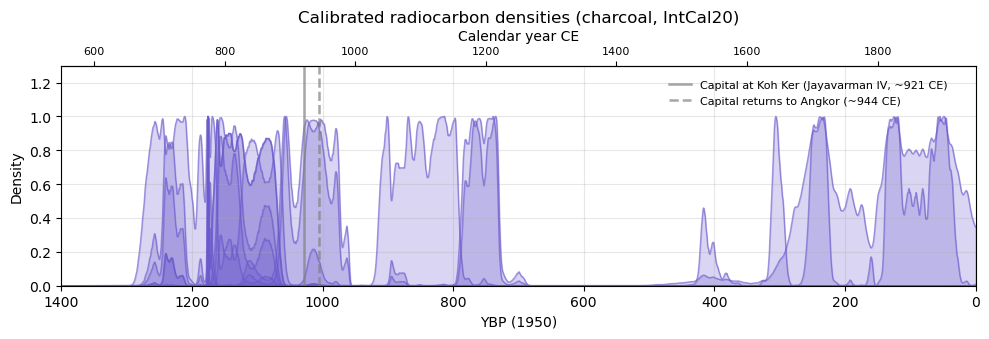

In [8]:
# plot the span of calibrated charcoal dates

char_mask = c14_data["material"] == "charcoal"
c14_char  = c14_data[char_mask].reset_index(drop=True)
cal_char  = [cal for cal, keep in zip(calibrations, char_mask) if keep]

x_grid = np.linspace(-1400, 0, 2000)

fig, ax = plt.subplots(figsize=(10, 3.5))

color = "slateblue"

for row, cal in zip(c14_char.itertuples(index=False), cal_char):
    y = cal.pdf(x_grid)
    y_norm = y / y.max() if y.max() > 0 else y
    ax.fill_between(x_grid, y_norm, alpha=0.25, color=color)
    ax.plot(x_grid, y_norm, alpha=0.6, color=color, lw=1)

ax.set_xlim(-1400, 0)
ax.set_ylim(0, 1.3)
ax.set_xlabel("YBP (1950)")
ax.xaxis.set_major_formatter(bp_age_formatter)

# --- CE axis on top ---
def bp_to_ce(x):
    return 1950 + x   # negative BP -> CE

def ce_to_bp(x):
    return x - 1950   # CE -> negative BP

secax = ax.secondary_xaxis(
    'top',
    functions=(bp_to_ce, ce_to_bp)
)
secax.set_xlabel("Calendar year CE")
secax.tick_params(labelsize=8)

ax.set_ylabel("Density")
ax.set_title("Calibrated radiocarbon densities (charcoal, IntCal20)")
ax.grid(alpha=0.3)

# --- historical events ---
events = [
    ("Capital at Koh Ker (Jayavarman IV, ~921 CE)", 921, "solid"),
    ("Capital returns to Angkor (~944 CE)", 944, "dashed"),
]

for label, year_ce, style in events:
    ybp = 1950 - year_ce
    x = -ybp

    ax.axvline(x, color="grey", alpha=0.7, linestyle=style, lw=1.8, label=label)

# Legend outside plot (or adjust as preferred)
ax.legend(
    fontsize=8,
    frameon=False,
    loc="upper right",  
    bbox_to_anchor=(0.98, 0.98),
)

plt.tight_layout()
plt.savefig("../Output/charcoal_calibrated_dates.png", bbox_inches="tight")
plt.show()


### Dates by Trench and Depth

Next, we plot the mean calibrated ages arranged by trench and corresponding depth. The aim is just to get an idea about the age-depth relationships across the trenches. 

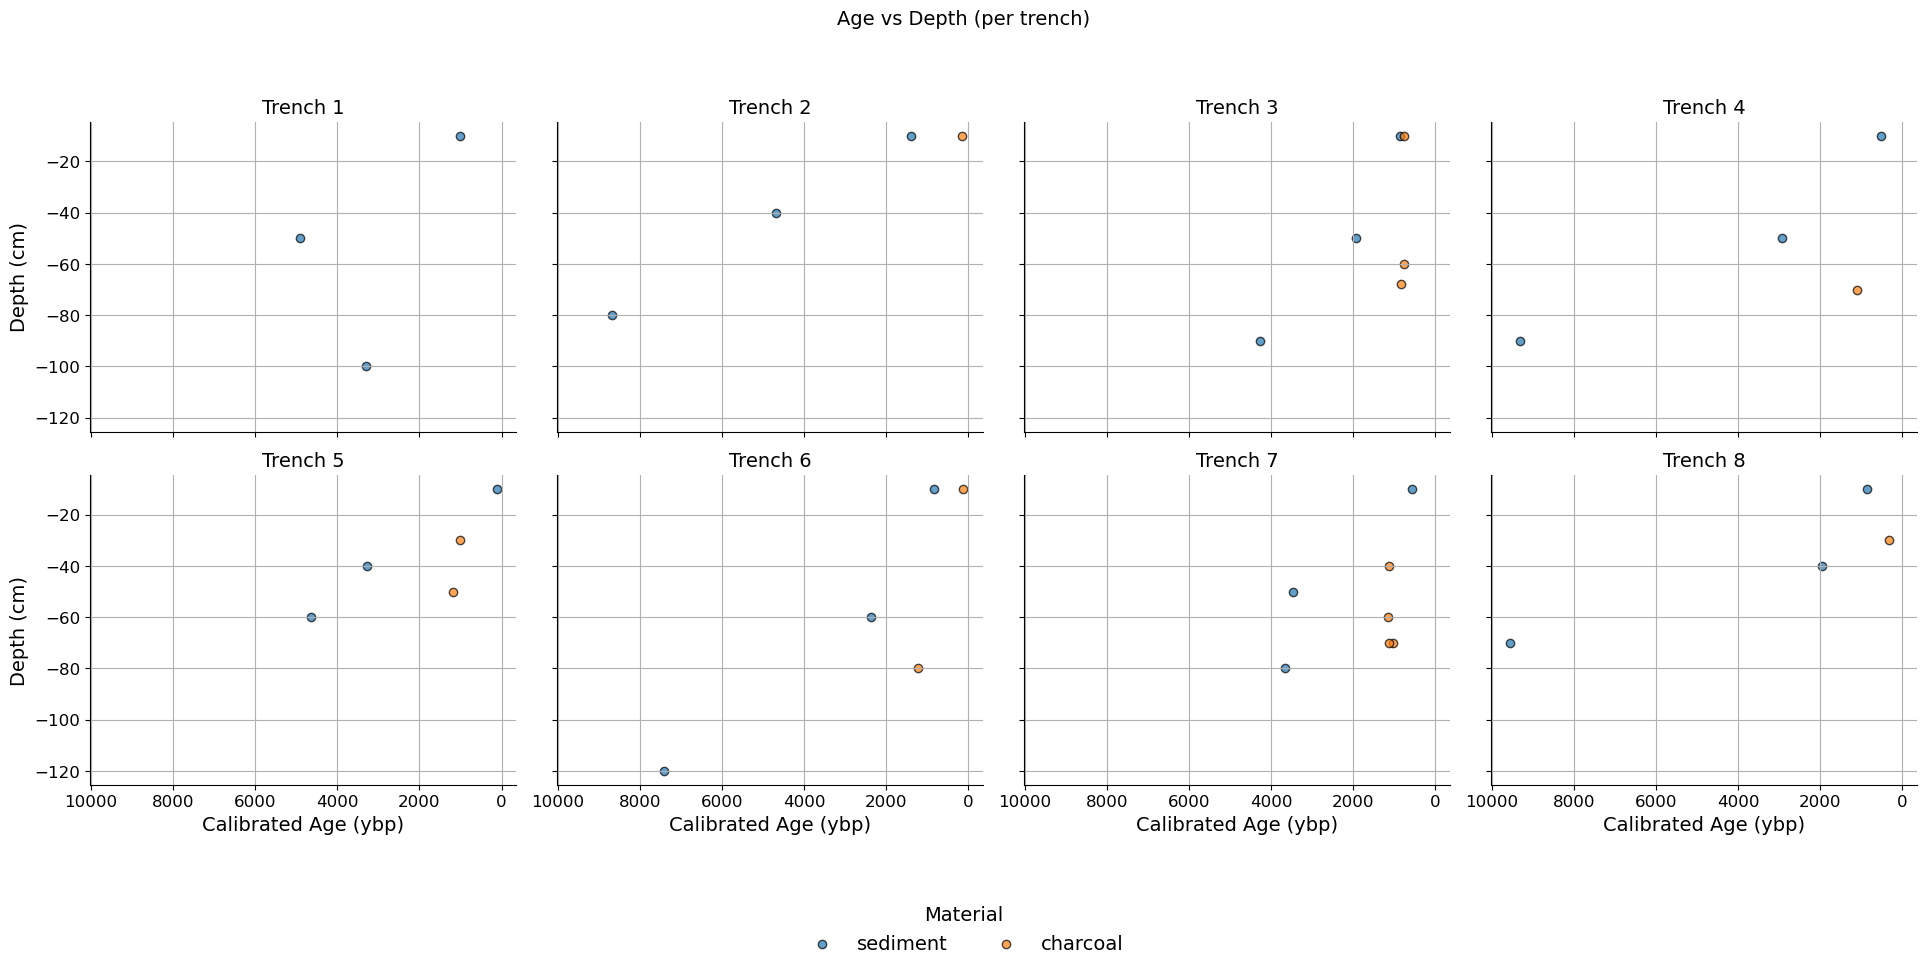

In [9]:
# make DBS negative for plotting
c14_data["depth_neg"] = -c14_data["depth"]

# Create the FacetGrid
g = sns.FacetGrid(c14_data, col="trench", hue="material", col_wrap=4, height=4, sharex=True, sharey=True)

# Plot scatter in each facet
g.map(plt.scatter, "ybp_cal", "depth_neg", edgecolor="black", alpha=0.7)

# Set axis labels and facet titles
g.set_axis_labels("Calibrated Age (ybp)", "Depth (cm)", fontsize=14)
g.set_titles("Trench {col_name}", size=14)

# Add a global title
plt.suptitle("Age vs Depth (per trench)", fontsize=14, y=1.05)

# Move the legend **outside the grid**.
g.add_legend(title="Material", loc='center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)

g.legend.get_title().set_fontsize(14)

# Adjust each axis and add grid
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(bp_age_formatter)
    ax.grid(True)
    ax.tick_params(axis="both", labelsize=12)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 1])

# Show plot
plt.show()

### Pooled Radiocarbon Ages

The aim here is to just look at the overall age-depth relationship across the sampled transect of tenches. Of course, we are then collapsing the variability, but we can then see that in general a site-wide age-depth relationship appears to be fairly consistent. Deeper sediments are clearly older on average across the transect.

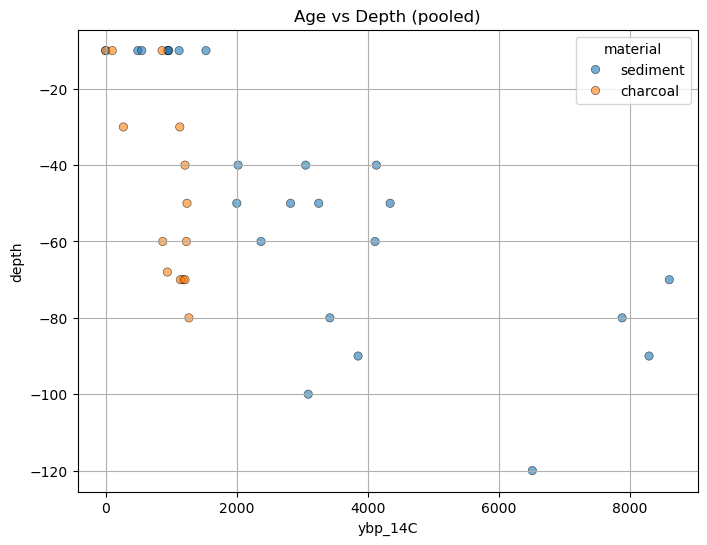

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data,
    x='ybp_14C',
    y='depth_neg',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('ybp_14C')
ax.set_ylabel('depth')
ax.set_title('Age vs Depth (pooled)')

plt.grid(True)
plt.show()

### Carbon-13 by Trench and Depth

Along with radiocarbon ages, the lab provides the $\delta^13C$ measurements for each sample. This can be used to help us understand the depositional processes at work and any depth-related bias in age offsets between charcoal and bulk sediment. $\delta^13C$ can reflect several things at once: shifts in C₃/C₄ vegetation inputs, charcoal/organic-matter composition, soil carbon turnover, hydrology/pedogenesis, and possibly anthropogenic inputs such as burning, cultivation, dumped organic material, or mixed occupation debris. So it is not a simple human-activity proxy. But, precisely because bulk sediment dates can be biased by changing carbon sources, plotting $\delta^13C$ alongside bulk sediment radiocarbon ages, charcoal ages, and depth helps show whether the bulk ages are behaving consistently or whether they may be tracking changing carbon pools.

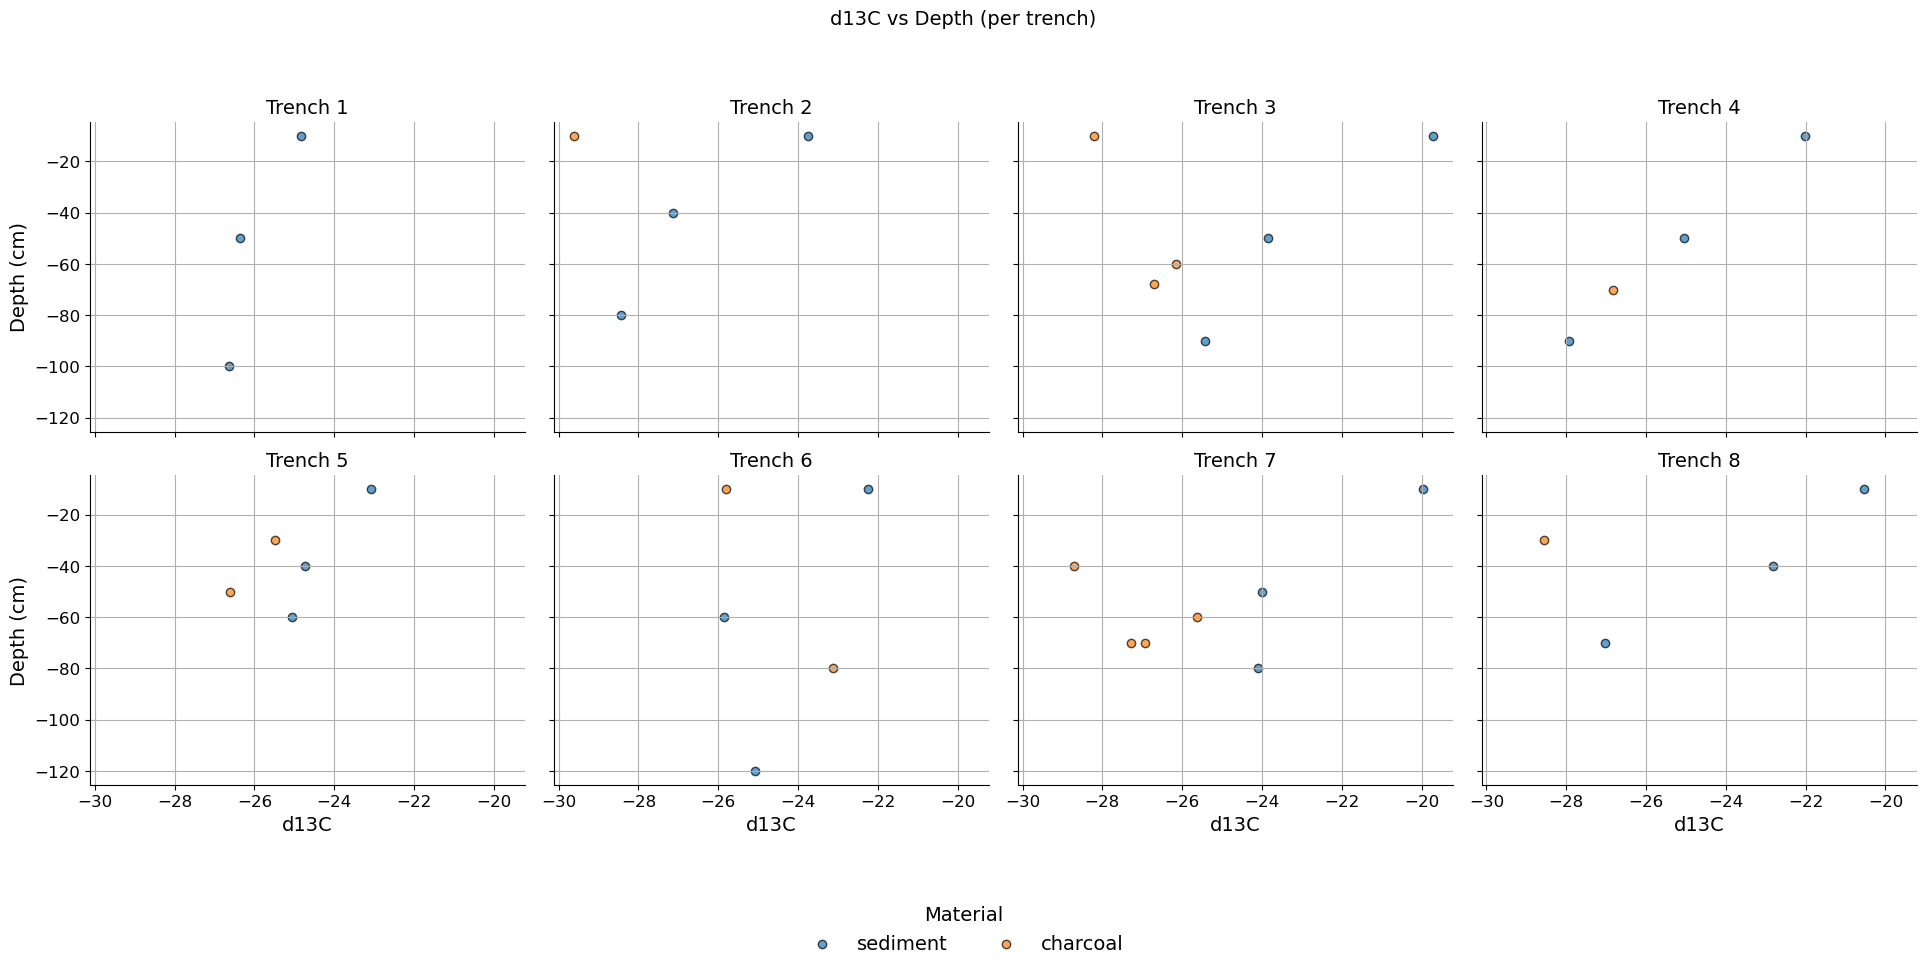

In [10]:
# make DBS negative for plotting
c14_data["depth_neg"] = -c14_data["depth"]

# Create the FacetGrid
g = sns.FacetGrid(c14_data, col="trench", hue="material", col_wrap=4, height=4, sharex=True, sharey=True)

# Plot scatter in each facet
g.map(plt.scatter, "d13C_ppm", "depth_neg", edgecolor="black", alpha=0.7)

# Set axis labels and facet titles
g.set_axis_labels("d13C", "Depth (cm)", fontsize=14)
g.set_titles("Trench {col_name}", size=14)

# Add a global title
plt.suptitle("d13C vs Depth (per trench)", fontsize=14, y=1.05)

# Move the legend **outside the grid**.
g.add_legend(title="Material", loc='center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)

g.legend.get_title().set_fontsize(14)

# Adjust each axis and add grid
for ax in g.axes.flat:
    ax.grid(True)
    ax.tick_params(axis="both", labelsize=12)


# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 1])

# Show plot
plt.show()

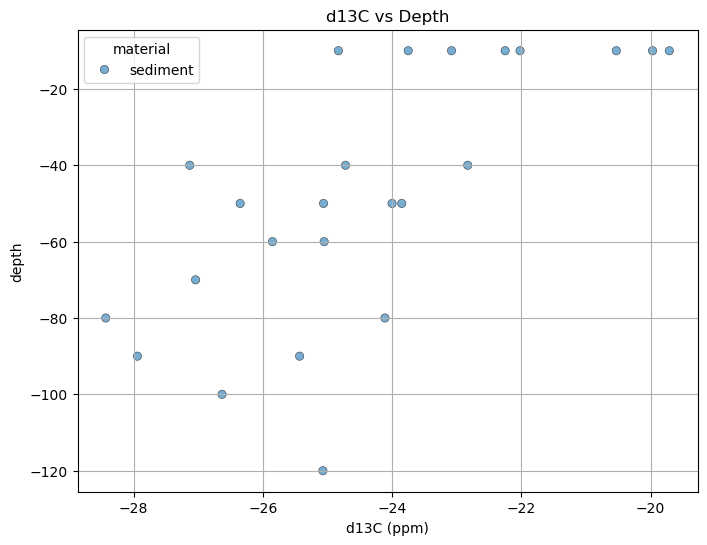

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data[c14_data['material'] == 'sediment'],
    x='d13C_ppm',
    y='depth_neg',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('d13C (ppm)')
ax.set_ylabel('depth')
ax.set_title('d13C vs Depth')

plt.grid(True)
plt.show()

## MagSus and Dates

Below, we plot a panel of magsus scans along with charcoal (the more directly related) radiocarbon date means in order to get a rough idea about the relationship between magsus anomalies and calendar age.

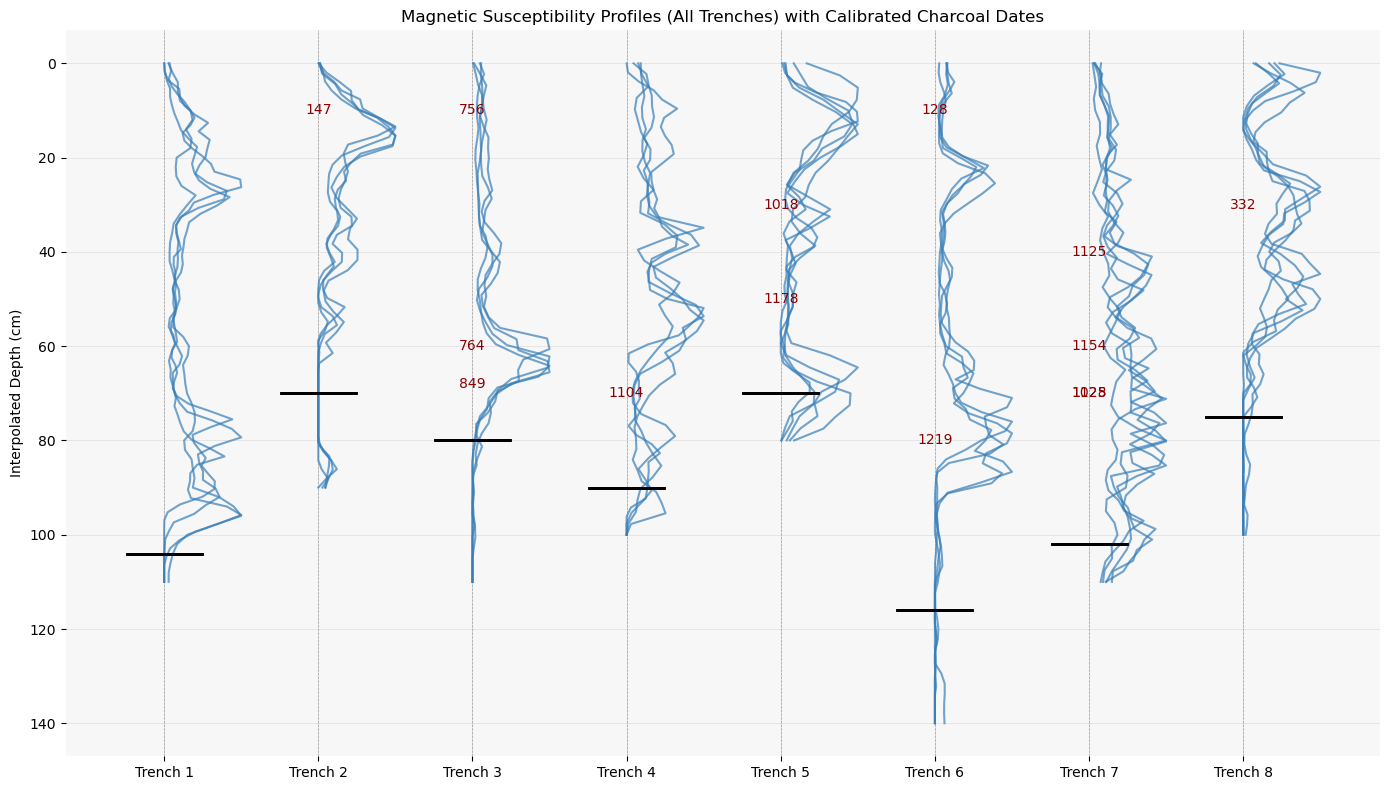

In [10]:
# Filter c14_data for charcoal dates
charcoal_data = c14_data[c14_data['material'] == 'charcoal']

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define a single color for all plots
uniform_color = '#377eb8'

# Plot each trench
offsets = []  # To store offsets for x-ticks
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    offsets.append(offset)
    
    # Add vertical zero line for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=offset - 0.5, xmax=offset + 0.5, color='black', linewidth=2)

    # Add calibrated radiocarbon dates for charcoal material
    trench_charcoal_data = charcoal_data[charcoal_data['trench'] == trench]
    for _, row in trench_charcoal_data.iterrows():
        ax.text(x=offset, y=row['depth'], s=f"{abs(int(row['ybp_cal']))}", 
                color='darkred', fontsize=10, ha='center', va='center')

# Set the x-ticks to the trench offsets and label them with the trench numbers
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {trench}' for trench in magsus['trench_id'].unique()])

# Invert y-axis to have depth increase downward
ax.invert_yaxis()

# Set labels and title
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches) with Calibrated Charcoal Dates')

# Apply minimal theme styling (like ggplot2's theme_minimal)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')  # Light grey background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the layout and show the plot
plt.tight_layout()

# Save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.png', dpi=300, bbox_inches='tight', format='png')
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.pdf', dpi=300, bbox_inches='tight', format='pdf')

# Display it
plt.show()


## Ceramics

Next, we need to ingest the ceramics data and collate it with trench and depth data. This is the slightly more complicated operation than earlier data wrangling cells because we have to correlate spit numbers with trench depths as the ceramics data come to us in a spreadsheet that doesn't contain depth information. They were recorded by spit in the field and analyzed as such. 

In [11]:
# --- CONFIG ---
xlsx_path = Path("../Data/KKPP all ceramics list form_2024 update.xlsx")
sheet_name  = 0      # or "Sheet1"
forced_zero_spits = {6011}   # known empty spit(s)

# --- LOAD ---
ceramic_df = pd.read_excel(xlsx_path, sheet_name=sheet_name, engine="openpyxl")

# --- NORMALIZE COLUMN NAMES ---
def normalize(col: str) -> str:
    return (
        str(col).strip()
        .replace("\n", " ")
        .replace(" ", "_")
        .replace("-", "_")
        .lower()
    )

ceramic_df.rename(columns={c: normalize(c) for c in ceramic_df.columns}, inplace=True)

# We now know the important columns are named:
# "trench", "layer", "spit", "date_collect", ..., "anything"

# drop useless 'anything' column if present
if "anything" in ceramic_df.columns:
    ceramic_df = ceramic_df.drop(columns=["anything"])

# forward-fill merged trench/layer cells
ceramic_df["trench"] = ceramic_df["trench"].ffill()
ceramic_df["layer"]  = ceramic_df["layer"].ffill()

# keep a raw spit string column before doing anything else
ceramic_df["spit_raw"] = ceramic_df["spit"].astype(str)

# parse dates (day-first)
if "date_collect" in ceramic_df.columns:
    ceramic_df["date_collect"] = pd.to_datetime(
        ceramic_df["date_collect"], dayfirst=True, errors="coerce"
    )

# --- COERCE ONLY COUNT/WEIGHT COLUMNS TO NUMERIC ---
count_cols  = [c for c in ceramic_df.columns if c.endswith("_count")]
weight_cols = [c for c in ceramic_df.columns if c.endswith("_g")]

for c in count_cols + weight_cols:
    ceramic_df[c] = pd.to_numeric(ceramic_df[c], errors="coerce")

# --- ROW-WISE TOTALS (PER BAG / ENTRY) ---
ceramic_df["ceramic_total_count"]     = ceramic_df[count_cols].sum(axis=1, skipna=True)
ceramic_df["ceramic_total_weight_g"]  = ceramic_df[weight_cols].sum(axis=1, skipna=True)

# --- EXPAND COMBINED SPITS (e.g. "6009&6010 (6011 Layer8)") ---
expanded_rows = []

for _, row in ceramic_df.iterrows():
    spit_str = str(row["spit_raw"]).strip()

    # detect any row mentioning more than one spit code
    if "&" in spit_str:
        # get all numeric spit IDs mentioned
        spit_ids = [int(s) for s in re.findall(r"\d+", spit_str)]

        # split into those that should be zero vs "active" spits
        zero_ids   = [s for s in spit_ids if s in forced_zero_spits]
        active_ids = [s for s in spit_ids if s not in forced_zero_spits]

        total_count  = row["ceramic_total_count"]
        total_weight = row["ceramic_total_weight_g"]

        if len(active_ids) == 0:
            # pathological case: all spits forced-zero → single zero row
            new_row = row.copy()
            new_row["spit"] = spit_ids[0]
            new_row["ceramic_total_count"]    = 0
            new_row["ceramic_total_weight_g"] = 0.0
            expanded_rows.append(new_row)
        else:
            # divide counts/weights across *active* spits only
            count_each  = total_count // len(active_ids)   # floor to integer
            weight_each = total_weight / len(active_ids)   # keep as float

            for spit_id in active_ids:
                new_row = row.copy()
                new_row["spit"] = spit_id
                new_row["ceramic_total_count"]    = count_each
                new_row["ceramic_total_weight_g"] = weight_each
                expanded_rows.append(new_row)

            # explicit zero rows for forced-zero spits (e.g. 6011)
            for spit_id in zero_ids:
                new_row = row.copy()
                new_row["spit"] = spit_id
                new_row["ceramic_total_count"]    = 0
                new_row["ceramic_total_weight_g"] = 0.0
                expanded_rows.append(new_row)

    else:
        # normal single-spit row
        # try to interpret spit_raw as integer code; if it fails, it'll become NaN
        try:
            row["spit"] = int(spit_str)
        except ValueError:
            row["spit"] = np.nan
        expanded_rows.append(row)

ceramic_df = pd.DataFrame(expanded_rows)

# --- DROP ROWS WITHOUT A VALID SPIT CODE ---
ceramic_df = ceramic_df[ceramic_df["spit"].notna()].copy()
ceramic_df["spit"] = ceramic_df["spit"].astype(int)

# --- COMPUTE DEPTH INTERVALS FROM SPIT CODE ---
# last 2–3 digits are spit index, each = 10 cm
ceramic_df["spit_index"]   = ceramic_df["spit"] % 1000
ceramic_df["depth_top_cm"] = ceramic_df["spit_index"] * 10
ceramic_df["depth_bot_cm"] = ceramic_df["depth_top_cm"] + 10
ceramic_df["depth_mid_cm"] = ceramic_df["depth_top_cm"] + 5

# optional meter versions
ceramic_df["depth_top_m"]  = ceramic_df["depth_top_cm"] / 100.0
ceramic_df["depth_bot_m"]  = ceramic_df["depth_bot_cm"] / 100.0
ceramic_df["depth_mid_m"]  = ceramic_df["depth_mid_cm"] / 100.0

# --- EXTRACT NUMERIC TRENCH ID (e.g. "Trench6" → 6) ---
ceramic_df["trench_id"] = (
    ceramic_df["trench"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

# --- KEEP ONLY THE COLUMNS NEEDED FOR MODELLING ---
ceramic_df = ceramic_df[
    [
        "trench_id",
        "depth_top_cm",
        "depth_bot_cm",
        "depth_mid_cm",
        "ceramic_total_count",
        "ceramic_total_weight_g",
    ]
].reset_index(drop=True)

ceramic_df.head(12)


/home/carleton@gea.mpg.de/miniconda3/envs/kkpp24/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/tmp/ipykernel_459635/1644304204.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ceramic_df["date_collect"] = pd.to_datetime(


,trench_id,depth_top_cm,depth_bot_cm,depth_mid_cm,ceramic_total_count,ceramic_total_weight_g
0,1,0,10,5,2.0,125.0
1,1,10,20,15,5.0,72.0
2,1,20,30,25,49.0,554.0
3,1,30,40,35,28.0,99.0
4,1,40,50,45,0.0,0.0
5,1,50,60,55,0.0,0.0
6,1,60,70,65,18.0,43.0
7,1,70,80,75,17.0,145.0
8,1,80,90,85,0.0,0.0
9,1,90,100,95,0.0,0.0


In [12]:
ceramic_df.groupby("trench_id")["ceramic_total_count"].sum()


trench_id
1     119.0
2     211.0
3     730.0
4     588.0
5     177.0
6    1895.0
7     296.0
8     268.0
Name: ceramic_total_count, dtype: float64

## Combined Plot

Now we add the collated ceramics data to the previous trench and magsus panel plot in order to see how ceramics counts and weights vary by depth along side the magsus scans and mean charcoal ages.

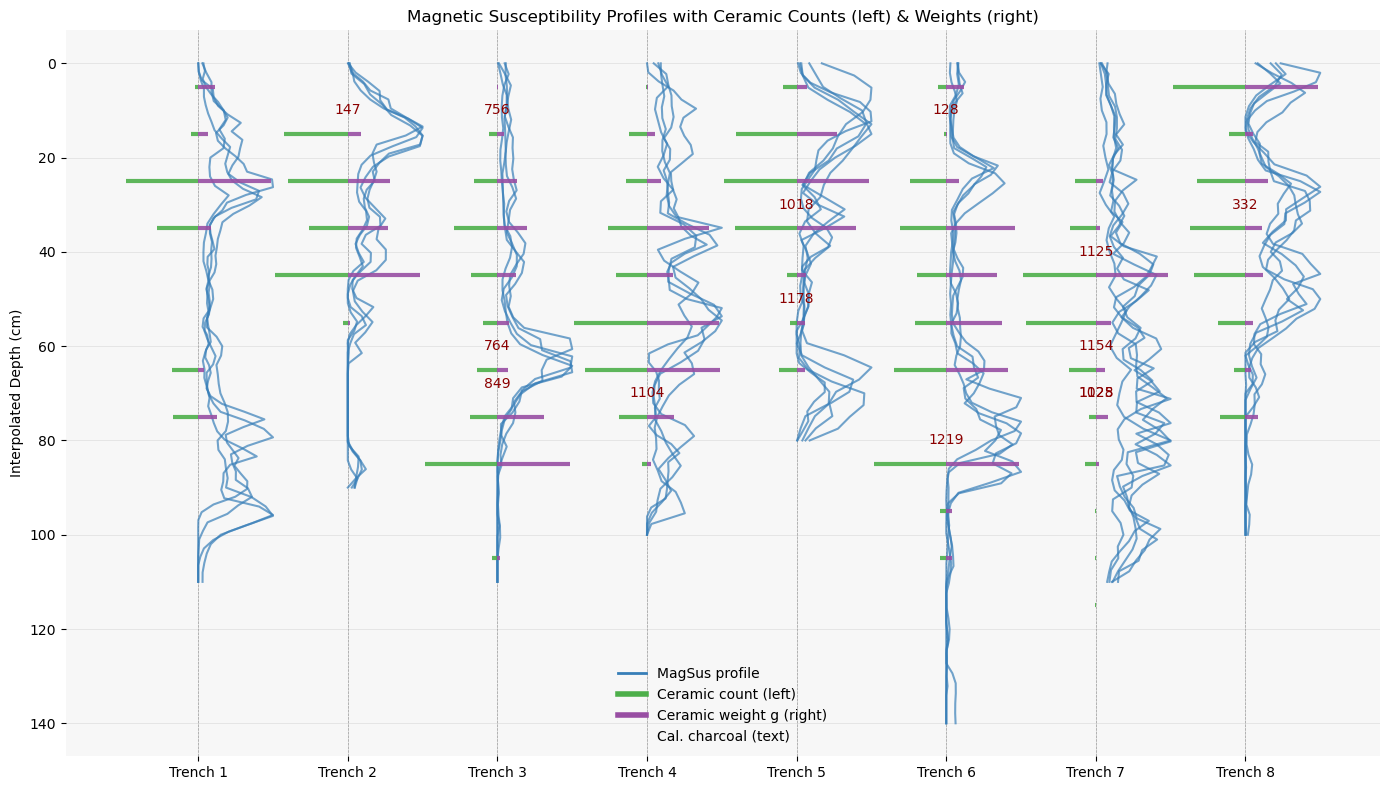

In [13]:
# Aggregate ceramics to ensure single row per trench/depth bin
cer_agg = (
    ceramic_df
    .groupby(['trench_id','depth_top_cm','depth_bot_cm','depth_mid_cm'], dropna=False)[
        ['ceramic_total_count','ceramic_total_weight_g']
    ]
    .sum()
    .reset_index()
)

profile_color = '#377eb8'
count_color   = '#4daf4a'
weight_color  = '#984ea3'

fig, ax = plt.subplots(figsize=(14, 8))
offsets = []

for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    record_ids  = trench_data['record_id'].unique()
    offset = i * 2
    offsets.append(offset)

    # vertical reference for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

    # plot magsus profiles
    for rec_id in record_ids:
        rd = trench_data[trench_data['record_id'] == rec_id]
        ax.plot(rd['susceptibility'] + offset, rd['depth'], color=profile_color, alpha=0.7)

    # ---- per-trench scale target: largest magsus horizontal excursion ----
    trench_span = np.nanmax(np.abs(trench_data['susceptibility'].values))
    # small margin so bars don't overdraw the furthest profile
    trench_span *= 0.97
    if not np.isfinite(trench_span) or trench_span == 0:
        trench_span = 1.0

    # ceramics overlay (per trench)
    cer_t = cer_agg[cer_agg['trench_id'] == trench].copy()
    if not cer_t.empty:
        # per-trench maxima for scaling
        max_count  = np.nanmax(cer_t['ceramic_total_count'].values) if cer_t['ceramic_total_count'].notna().any() else 0
        max_weight = np.nanmax(cer_t['ceramic_total_weight_g'].values) if cer_t['ceramic_total_weight_g'].notna().any() else 0

        # scale so the largest bar in this trench reaches the magsus span
        count_scale  = (trench_span / max_count)  if max_count  and np.isfinite(max_count)  else 0.0
        weight_scale = (trench_span / max_weight) if max_weight and np.isfinite(max_weight) else 0.0

        for _, r in cer_t.iterrows():
            y = r['depth_mid_cm']
            # counts (left of axis)
            cval = 0 if np.isnan(r['ceramic_total_count']) else r['ceramic_total_count']
            if cval > 0 and count_scale > 0:
                ax.hlines(y=y,
                          xmin=offset - cval * count_scale,
                          xmax=offset,
                          color=count_color, linewidth=3, alpha=0.9)
            # weights (right of axis)
            wval = 0.0 if np.isnan(r['ceramic_total_weight_g']) else r['ceramic_total_weight_g']
            if wval > 0 and weight_scale > 0:
                ax.hlines(y=y,
                          xmin=offset,
                          xmax=offset + wval * weight_scale,
                          color=weight_color, linewidth=3, alpha=0.9)

    # charcoal labels (optional; comment out if not needed)
    trench_charcoal = charcoal_data[charcoal_data['trench'] == trench]
    for _, row in trench_charcoal.iterrows():
        ax.text(x=offset, y=row['depth'], s=f"{abs(int(row['ybp_cal']))}",
                color='darkred', fontsize=10, ha='center', va='center')

# axis formatting
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {t}' for t in magsus['trench_id'].unique()])
ax.invert_yaxis()
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles with Ceramic Counts (left) & Weights (right)')

# minimal theme
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')
for side in ['top','right','left','bottom']:
    ax.spines[side].set_visible(False)

# legend
legend_elems = [
    Line2D([0], [0], color=profile_color, lw=2, label='MagSus profile'),
    Line2D([0], [0], color=count_color,  lw=4, label='Ceramic count (left)'),
    Line2D([0], [0], color=weight_color, lw=4, label='Ceramic weight g (right)'),
    Line2D([0], [0], color='darkred', lw=0, marker=None, label='Cal. charcoal (text)'),
]
ax.legend(handles=legend_elems, loc='lower center', frameon=False)

plt.tight_layout()
plt.savefig("../Output/trench_panel.png", bbox_inches="tight")
plt.show()


## Modelling the Process

## Latent-process model for human influence and its indicators

We model a latent *human influence* process $I_{d,t}$ (depth $d$, trench $t$)
as a first-order random walk with drift:

$$
I_{d,t} = I_{d-1,t} + \epsilon_{d,t}, \qquad 
\epsilon_{d,t} \sim \mathcal{N}(\delta_t, \sigma_{I,t}^2)
$$

with initial state

$$
I_{0,t} \sim \mathcal{N}(I_0, \sigma_{I0}^2)
$$

where $\delta_t$ controls the mean depth-wise drift and $\sigma_{I,t}$
controls the roughness of the latent trajectory.

### Observation models

Magnetic susceptibility ($y_{d,t}$) and artifact abundance ($x_{d,t}$)
are conditionally independent observations of the same latent process:

$$
\begin{aligned}
y_{d,t} &\sim \mathcal{N}(\alpha_{y,t} + \beta_{y,t} I_{d,t},\, \sigma_y^2) \\
x_{d,t} &\sim \mathrm{NegBinomial}(\mu_{d,t}, \phi), \quad
\mu_{d,t} = \exp(\alpha_{x,t} + \beta_x I_{d,t})
\end{aligned}
$$

Hierarchical priors allow trench-level intercepts and slopes:

$$
\begin{aligned}
\alpha_{y,t} &\sim \mathcal{N}(\alpha_y, \sigma_{\alpha_y}^2),
&\beta_{y,t} &\sim \mathcal{N}(\beta_y, \sigma_{\beta_y}^2) \\
\alpha_{x,t} &\sim \mathcal{N}(\alpha_x, \sigma_{\alpha_x}^2),
&\beta_x &\sim \mathcal{N}(\bar\beta_x, \sigma_{\beta_x}^2)
\end{aligned}
$$

### Interpretation

- $I_{d,t}$ represents latent *human influence intensity* through the profile.  
- $y_{d,t}$ (magnetic susceptibility) and $x_{d,t}$ (artifacts) are distinct but linked sensors of this underlying process.  
- The model jointly reconstructs $I_{d,t}$ as a smooth, depth-wise stochastic function consistent with both signals.


WORKING HERE

## Test: Can magnetic susceptibility alone recover the human influence process?

Let $p(I \mid y, x)$ denote the posterior of the latent process $I$
conditioned on both observed indicators, and $p(I \mid y)$
the posterior conditioned on magnetic susceptibility alone.

The goal is to evaluate whether $y$ alone contains sufficient information
to reconstruct $I$:

$$
p(I \mid y) \;\approx\; p(I \mid y, x)
$$

If this holds, then magnetic susceptibility can serve as a standalone
field proxy for human influence intensity.

### Practical comparison

We fit two models with identical priors:

1. **Joint model:** $p(I, \theta \mid y, x)$ → posterior $p(I \mid y, x)$  
2. **Magsus-only model:** $p(I, \theta \mid y)$ → posterior $p(I \mid y)$  

We then compare the posterior functions $I_{d,t}$ across depths:

$$
\Delta I_{d,t} = \mathbb{E}[I_{d,t} \mid y,x] - \mathbb{E}[I_{d,t} \mid y]
$$

and assess overlap of their credible regions (e.g., 90% HPD bands) or
divergence measures (e.g., mean absolute difference, KL divergence).

Similarity implies that $y$ subsumes the information $x$ provides;
divergence indicates that artifact counts contain additional, non-redundant
information about human influence.


# Simulation Study

Below we evaluate the model using simulated data where the true latent process
is known. This allows us to assess how well the model can recover the LHIF.

In [16]:
T = 8            # trenches
R = 4            # magsus replicates per trench
BIN = 10.0       # 10 cm ceramic spits

# containers
Z_all        = []   # per-trench depth grids: (D_t,1)
edges_all    = []   # per-trench bin edges: (B_t+1,)
A_all        = []   # per-trench (B_t, D_t)
I_true_all   = []   # latent per trench: (D_t,)
obs_idx_all  = []   # per-trench index array into Z_t
y_reps_all   = []   # per-trench list of R replicate arrays
y_std_all    = []   # per-trench list of magsus replicate std devs
c_all        = []   # per-trench ceramic counts per bin

# --- helper: Matern-3/2 kernel ---
def matern32(x, y, ell, eta):
    r = np.abs(x - y.T)
    s = np.sqrt(3) * r / ell
    return (eta**2) * (1.0 + s) * np.exp(-s)

# --- true hyperparameters (varied by trench) ---
ell_true_t      = rng.uniform(7.0, 16.0, size=T)
eta_true_t      = rng.uniform(0.8, 1.4, size=T)
sigma_y_true_t  = rng.uniform(0.18, 0.35, size=T)  # magsus noise

# ceramics link (per-trench, could also be made hierarchical if you want)
a_true_t        = rng.normal(1.2, 0.25, size=T)    # NB intercept
b_true_t        = rng.normal(0.85, 0.05, size=T)   # NB slope
alpha_true_t    = rng.uniform(0.8, 2.0, size=T)    # NB overdispersion

# --- magsus link: hierarchical slope, trench-specific intercepts ---

# site-level magsus slope hyperparameters
b_mag_mu_true    = rng.normal(2.0, 0.005)           # site-level mean slope
b_mag_sigma_true = np.abs(rng.normal(0.03, 0.01))    # site-level slope SD (>0)

# trench-specific magsus intercepts and slopes
a_mag_true_t = rng.normal(0.0, 0.5, size=T)                      # unpooled intercepts
b_mag_true_t = rng.normal(b_mag_mu_true, b_mag_sigma_true, size=T)  # pooled slopes

for t in range(T):
    # --- ragged trench depth & grid ---
    max_depth = float(rng.uniform(80, 150))             # cm
    # irregular sampling along depth (denser near 0–100 cm)
    D_t = int(rng.integers(90, 140))
    Z_t = np.sort(rng.uniform(0, max_depth, size=D_t))[:, None]

    # --- latent I_t(d) on this grid ---
    K_t = matern32(Z_t, Z_t, ell_true_t[t], eta_true_t[t]) + 1e-6*np.eye(D_t)
    I_true = rng.multivariate_normal(mean=np.zeros(D_t), cov=K_t)

    # --- magsus observation locations (shared across replicates) ---
    n_obs = int(rng.integers(24, 36))
    obs_idx = np.sort(rng.choice(D_t, size=n_obs, replace=False))

    # magsus mean at observed depths: a_mag_t + b_mag_t * I_true
    mu_y = a_mag_true_t[t] + b_mag_true_t[t] * I_true[obs_idx]

    # R replicate magsus profiles
    # raw magsus replicates (unstandardized)
    y_raw_reps = [
        a_mag_true_t[t] + b_mag_true_t[t] * I_true[obs_idx]
        + rng.normal(0, sigma_y_true_t[t], size=n_obs)
        for _ in range(R)
    ]

    # compute standardization constants using *all replicates at once*
    y_concat = np.concatenate(y_raw_reps)
    mean_y = y_concat.mean()
    std_y  = y_concat.std() + 1e-9   # safety to avoid zero division

    # standardized magsus
    y_reps = [(y - mean_y)/std_y for y in y_raw_reps]

    # --- ceramic bins per 10 cm down to trench max ---
    edges_t = np.arange(0.0, max_depth + BIN, BIN)
    if edges_t[-1] < max_depth - 1e-9:
        edges_t = np.r_[edges_t, max_depth]  # ensure last edge hits max
    B_t = len(edges_t) - 1

    # build A_t: average the I values whose Z fall in each bin
    A_t = np.zeros((B_t, D_t))
    zflat = Z_t[:, 0]
    for b in range(B_t):
        lo, hi = edges_t[b], edges_t[b+1]
        mask = (zflat >= lo) & (zflat < (hi if b < B_t-1 else hi + 1e-12))
        idx = np.where(mask)[0]
        if idx.size == 0:
            # if no depths in bin, snap to nearest depth
            k = np.argmin(np.abs(zflat - 0.5*(lo+hi)))
            A_t[b, k] = 1.0
        else:
            A_t[b, idx] = 1.0 / idx.size

    zbar_t = A_t @ I_true
    mu_t   = np.exp(a_true_t[t] + b_true_t[t] * zbar_t)

    # Gamma–Poisson mixture to simulate NB(mu, alpha)
    lam = rng.gamma(shape=alpha_true_t[t], scale=mu_t/alpha_true_t[t])
    c_t = rng.poisson(lam)

    # store
    Z_all.append(Z_t)
    edges_all.append(edges_t)
    A_all.append(A_t)
    I_true_all.append(I_true)
    obs_idx_all.append(obs_idx)
    y_reps_all.append(y_reps)
    y_std_all.append(std_y)
    c_all.append(c_t)


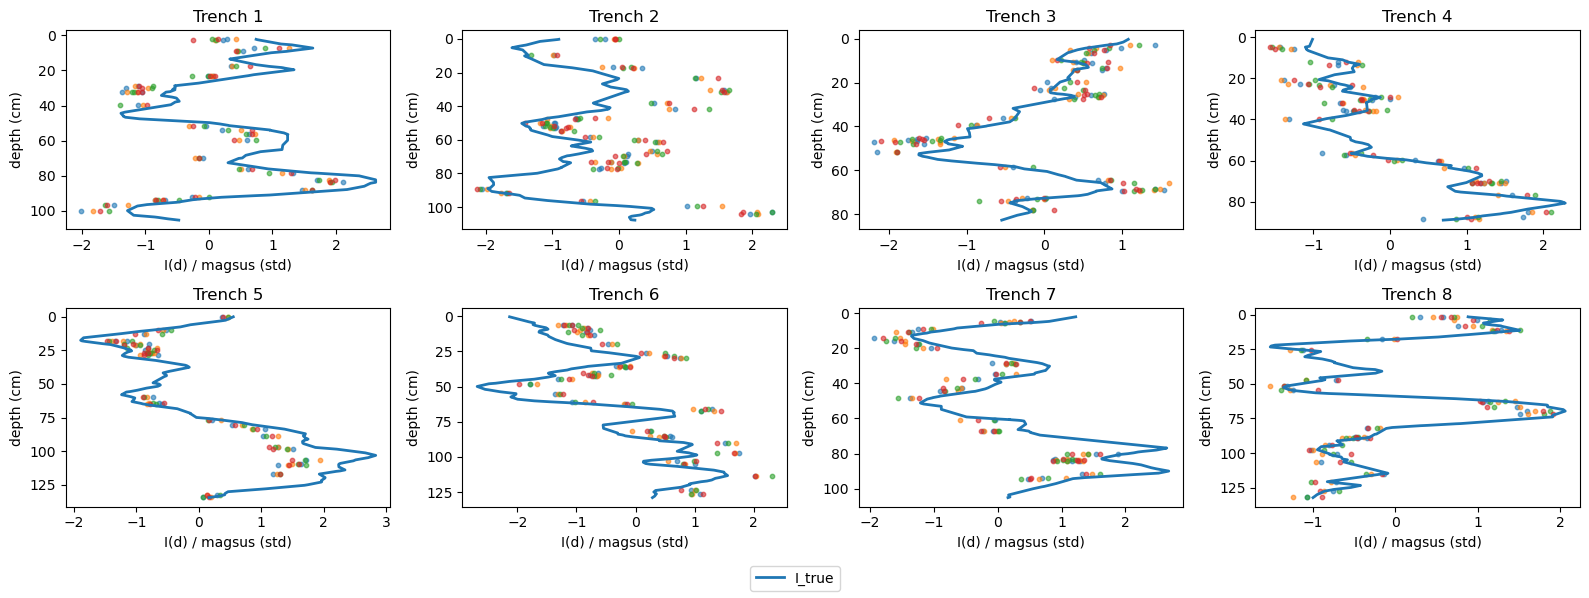

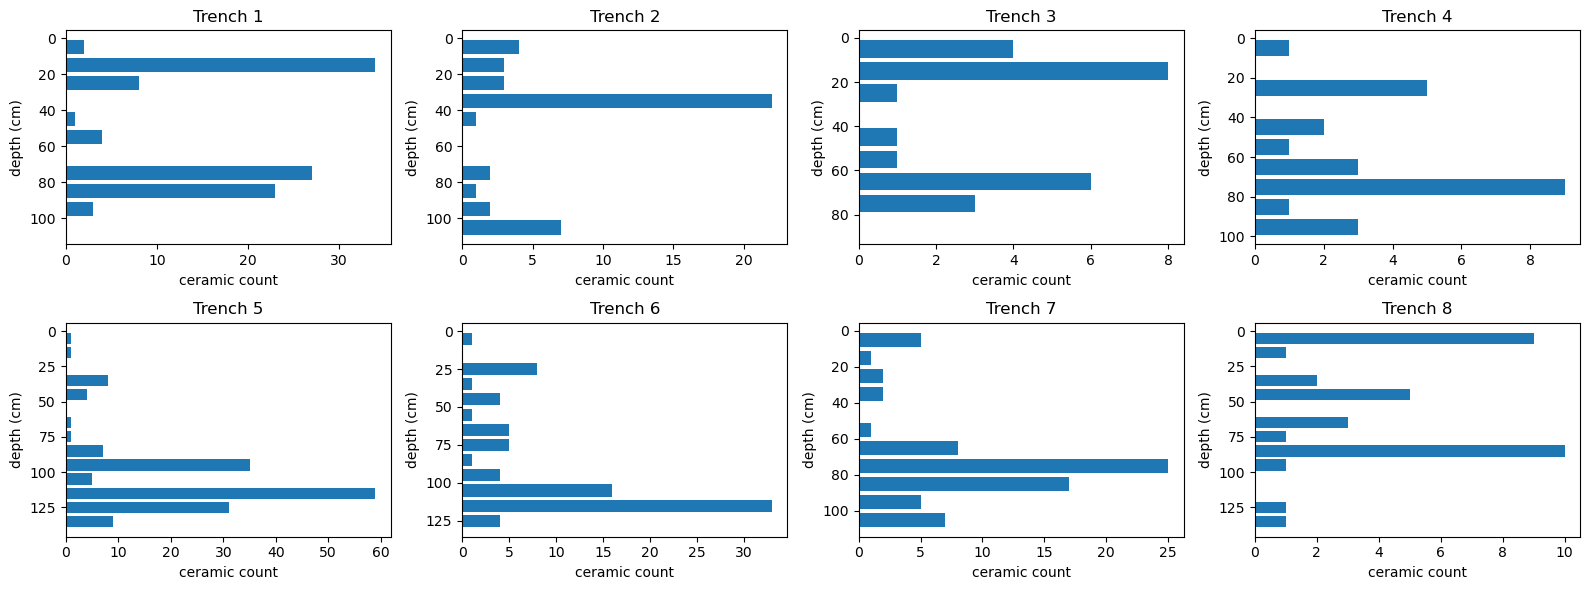

In [17]:
# --- plot simulated data: I(d), magsus, ceramics ---

T = len(Z_all)

# 1) I_true(d) + magsus by trench
ncols = min(4, T)
nrows = math.ceil(T / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=False)
axes = np.atleast_1d(axes).reshape(nrows, ncols)

for t, ax in enumerate(axes.flat):
    if t >= T:
        ax.axis("off")
        continue

    Z_t = Z_all[t][:, 0]             # depths
    I_t = I_true_all[t]              # true latent I(d)
    obs_idx = obs_idx_all[t]
    dep_obs = Z_t[obs_idx]           # depths where magsus observed

    # I(d)
    ax.plot(I_t, Z_t, lw=2, label="I_true")

    # magsus replicates (already standardized in sim cell)
    for r, y in enumerate(y_reps_all[t]):
        ax.scatter(y, dep_obs, s=10, alpha=0.6)

    ax.invert_yaxis()
    ax.set_title(f"Trench {t+1}")
    ax.set_xlabel("I(d) / magsus (std)")
    ax.set_ylabel("depth (cm)")

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=len(handles))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


# 2) Ceramics by trench
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=False)
axes = np.atleast_1d(axes).reshape(nrows, ncols)

for t, ax in enumerate(axes.flat):
    if t >= T:
        ax.axis("off")
        continue

    edges_t = edges_all[t]
    bin_mids = 0.5 * (edges_t[:-1] + edges_t[1:])
    counts_t = c_all[t]

    ax.barh(bin_mids, counts_t, height=(edges_t[1]-edges_t[0])*0.8)
    ax.invert_yaxis()
    ax.set_title(f"Trench {t+1}")
    ax.set_xlabel("ceramic count")
    ax.set_ylabel("depth (cm)")

plt.tight_layout()
plt.savefig("../Output/trench_panels_simulated.png", bbox_inches="tight")
plt.show()


In [18]:
# Bottle the simulated data
simdata = dict(
    T = T,
    trench_ids = list(range(T)),

    Z_all = Z_all,
    D_all = [Z.shape[0] for Z in Z_all],

    obs_idx_all = obs_idx_all,
    y_reps_all = y_reps_all,
    y_std_all = y_std_all,
    n_reps_all = [len(rep_list) for rep_list in y_reps_all],

    c_all = c_all,
    A_all = A_all,
    edges_all = edges_all,
    B_all = [len(c) for c in c_all],

    # NEW: latent I(d) truth per trench
    I_true_all = I_true_all,
)


In [19]:
sim_params = {
    "ell_t": ell_true_t,
    "eta_t": eta_true_t,
    "a_t": a_true_t,
    "b_t": b_true_t,
    "a_mag_t": a_mag_true_t,
    "b_mag_t": b_mag_true_t / np.array(simdata["y_std_all"]),
    "phi_t": alpha_true_t,
    "sigma_y_t": sigma_y_true_t / np.array(simdata["y_std_all"]),
}

## PYMC Model
Next, we create a reusable wrapper around a pymc model that matches our specification.

In [20]:
def run_hsgp(
    data,
    use_ceramics: bool = True,
    draws: int = 1000,
    tune: int = 1000,
    chains: int = 2,
    seed: int = 123,
    M: int = 50,
    C: float = 4.0,
    PPC: bool = True,
):
    """
    data: dict with keys
        - "T": int
        - "Z_all": list of length T, each (D_t, 1)
        - "obs_idx_all": list of length T, each (n_obs_t,) int
        - "y_reps_all": list of length T, each is list of R_t arrays (n_obs_t,)
        - "A_all": list of length T, each (B_t, D_t)      [required if use_ceramics]
        - "c_all": list of length T, each (B_t,)          [required if use_ceramics]
    """

    T           = data["T"]
    Z_all       = data["Z_all"]
    obs_idx_all = data["obs_idx_all"]
    y_reps_all  = data["y_reps_all"]

    if use_ceramics:
        A_all   = data["A_all"]
        c_all   = data["c_all"]

    with pm.Model() as hsgp:
        # per-trench GP hypers
        ell_t = pm.HalfNormal("ell_t", 10.0, shape=T)
        eta_t = pm.HalfNormal("eta_t", 1.0,  shape=T)

        # magsus noise per trench (shared across replicates)
        sigma_y_t = pm.HalfNormal("sigma_y_t", 0.5, shape=T)

        # --- magsus link hyperpriors (hierarchical slope), trench-specific intercepts ---
        a_mag_t = pm.Normal("a_mag_t", 0.0, 1.0, shape=T)  # unpooled intercepts

        # magsus hierarchical slopes (all > 0 via log-space)
        log_b_mag_mu    = pm.Normal("log_b_mag_mu", 0.0, 1.0)        # centre around log(1) = 0
        log_b_mag_sigma = pm.HalfNormal("log_b_mag_sigma", 0.3)
        
        eps_log_b_mag_t = pm.Normal("eps_log_b_mag_t", 0.0, 1.0, shape=T)
        log_b_mag_t     = pm.Deterministic(
            "log_b_mag_t",
            log_b_mag_mu + eps_log_b_mag_t * log_b_mag_sigma
        )

        b_mag_t = pm.Deterministic("b_mag_t", pt.exp(log_b_mag_t))   # slopes > 0

        # --- ceramics link + NB overdispersion ---
        if use_ceramics:
            # trench-specific intercepts
            a_t = pm.Normal("a_t", 0.0, 1.5, shape=T)

            # hierarchical slopes
            # ceramics hierarchical slopes (all > 0 via log-space)
            log_b_mu    = pm.Normal("log_b_mu", 0.0, 0.3)
            log_b_sigma = pm.HalfNormal("log_b_sigma", 0.3)
            
            eps_log_b_t = pm.Normal("eps_log_b_t", 0.0, 1.0, shape=T)
            log_b_t     = pm.Deterministic("log_b_t", log_b_mu + eps_log_b_t * log_b_sigma)

            b_t         = pm.Deterministic("b_t", pt.exp(log_b_t))

            phi_t = pm.HalfNormal("phi_t", 1.0, shape=T)

        for t in range(T):
            Z_t = np.asarray(Z_all[t], dtype="float64")  # (D_t, 1)

            # GP prior via HSGP
            cov_t  = pm.gp.cov.Matern32(1, ell_t[t]) * (eta_t[t]**2)
            hsgp_t = pm.gp.HSGP(m=[M], c=C, cov_func=cov_t)
            I_t    = hsgp_t.prior(f"I_{t}", X=Z_t)   # (D_t,)

            # --- magsus channel (always) ---
            idx_t   = pm.Data(f"obs_idx_{t}", np.asarray(obs_idx_all[t], dtype="int64"))
            # stack replicates into (R_t, n_obs_t)
            y_mat_t = np.vstack([np.asarray(y, dtype="float64") for y in y_reps_all[t]])

            pm.Normal(
                f"y_obs_{t}",
                mu=a_mag_t[t] + b_mag_t[t] * I_t[idx_t][None, :],
                sigma=sigma_y_t[t],
                observed=y_mat_t,
            )

            # --- ceramics channel (optional) ---
            if use_ceramics:
                A_t_data = pm.Data(f"A_{t}", A_all[t].astype(float))  # (B_t, D_t)
                zbar = pt.dot(A_t_data, I_t)                          # (B_t,)
                log_mu = a_t[t] + b_t[t] * zbar
                mu     = pm.Deterministic(f"mu_w_{t}", pt.exp(log_mu))

                pm.NegativeBinomial(
                    f"c_obs_{t}",
                    mu=mu,
                    alpha=phi_t[t],
                    observed=c_all[t].astype(int),
                )

        # main sampling
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=0.98,
            random_seed=seed,
        )

        # optional posterior predictive
        if PPC:
            ppc_vars = [f"y_obs_{t}" for t in range(T)]
            if use_ceramics:
                ppc_vars += [f"c_obs_{t}" for t in range(T)]

            ppc_idata = pm.sample_posterior_predictive(
                idata,
                var_names=ppc_vars,
            )
            idata.extend(ppc_idata)

    return idata


In [21]:
idata_full_simulated   = run_hsgp(simdata, use_ceramics=True, seed=seed, chains=nchains)
idata_magsus_simulated = run_hsgp(simdata, use_ceramics=False, seed=seed, chains=nchains)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ell_t, eta_t, sigma_y_t, a_mag_t, log_b_mag_mu, log_b_mag_sigma, eps_log_b_mag_t, a_t, log_b_mu, log_b_sigma, eps_log_b_t, phi_t, I_0_hsgp_coeffs, I_1_hsgp_coeffs, I_2_hsgp_coeffs, I_3_hsgp_coeffs, I_4_hsgp_coeffs, I_5_hsgp_coeffs, I_6_hsgp_coeffs, I_7_hsgp_coeffs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 727 seconds.
Sampling: [c_obs_0, c_obs_1, c_obs_2, c_obs_3, c_obs_4, c_obs_5, c_obs_6, c_obs_7, y_obs_0, y_obs_1, y_obs_2, y_obs_3, y_obs_4, y_obs_5, y_obs_6, y_obs_7]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ell_t, eta_t, sigma_y_t, a_mag_t, log_b_mag_mu, log_b_mag_sigma, eps_log_b_mag_t, I_0_hsgp_coeffs, I_1_hsgp_coeffs, I_2_hsgp_coeffs, I_3_hsgp_coeffs, I_4_hsgp_coeffs, I_5_hsgp_coeffs, I_6_hsgp_coeffs, I_7_hsgp_coeffs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 493 seconds.
Sampling: [y_obs_0, y_obs_1, y_obs_2, y_obs_3, y_obs_4, y_obs_5, y_obs_6, y_obs_7]


Output()

In [22]:
# --- get summaries (keep them in separate variables) ---
posterior_summary_full = az.summary(idata_full_simulated)
posterior_summary_mag  = az.summary(idata_magsus_simulated)

# optional: also keep CSVs on disk
posterior_summary_full.to_csv("../Output/posterior_summary_sim_full.csv")
posterior_summary_mag.to_csv("../Output/posterior_summary_sim_mag.csv")


In [23]:

# --- plotting function ---

def plot_rhat_ess_summaries(df_full, df_mag,
                             ess_col="ess_bulk",
                             rhat_col="r_hat",
                             ess_threshold=400,
                             rhat_threshold=1.01,
                             outpath_prefix="../Output/mcmc_convergence_diagnostics"):
    """
    Make a 2x2 panel summary of ESS and R-hat distributions
    for two model runs.

    df_full : DataFrame from az.summary for the full model
    df_mag  : DataFrame from az.summary for the magsus-only model
    """

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    ax_full_ess, ax_full_rhat, ax_mag_ess, ax_mag_rhat = axes.flat

    # convenience
    ess_full  = df_full[ess_col].dropna()
    rhat_full = df_full[rhat_col].dropna()
    ess_mag   = df_mag[ess_col].dropna()
    rhat_mag  = df_mag[rhat_col].dropna()

    # ---- full model: ESS ----
    ax_full_ess.hist(ess_full, bins=30, density=True, alpha=0.7)
    ax_full_ess.axvline(ess_threshold, color="r", ls="--", label=f"threshold = {ess_threshold}")
    ax_full_ess.set_title("Full model: ESS")
    ax_full_ess.set_xlabel("ESS (bulk)")
    ax_full_ess.set_ylabel("density")
    ax_full_ess.legend()

    # ---- full model: R-hat ----
    ax_full_rhat.hist(rhat_full, bins=30, density=True, alpha=0.7)
    ax_full_rhat.axvline(rhat_threshold, color="r", ls="--", label=f"threshold = {rhat_threshold}")
    ax_full_rhat.set_title("Full model: $\hat R$")
    ax_full_rhat.set_xlabel("$\hat R$")
    ax_full_rhat.set_ylabel("density")
    ax_full_rhat.legend()
    # zoom in around 1 a bit
    ax_full_rhat.set_xlim(0.99, max(1.02, rhat_full.max()*1.01))

    # ---- magsus-only: ESS ----
    ax_mag_ess.hist(ess_mag, bins=30, density=True, alpha=0.7)
    ax_mag_ess.axvline(ess_threshold, color="r", ls="--", label=f"threshold = {ess_threshold}")
    ax_mag_ess.set_title("Magsus-only model: ESS")
    ax_mag_ess.set_xlabel("ESS (bulk)")
    ax_mag_ess.set_ylabel("density")
    ax_mag_ess.legend()

    # ---- magsus-only: R-hat ----
    ax_mag_rhat.hist(rhat_mag, bins=30, density=True, alpha=0.7)
    ax_mag_rhat.axvline(rhat_threshold, color="r", ls="--", label=f"threshold = {rhat_threshold}")
    ax_mag_rhat.set_title("Magsus-only model: $\hat R$")
    ax_mag_rhat.set_xlabel("$\hat R$")
    ax_mag_rhat.set_ylabel("density")
    ax_mag_rhat.legend()
    ax_mag_rhat.set_xlim(0.99, max(1.02, rhat_mag.max()*1.01))

    plt.tight_layout()
    plt.savefig(Path(outpath_prefix), bbox_inches="tight")
    plt.show()


<>:37: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:56: SyntaxWarning: invalid escape sequence '\h'
<>:37: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:56: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_364805/203799242.py:37: SyntaxWarning: invalid escape sequence '\h'
  ax_full_rhat.set_title("Full model: $\hat R$")
/tmp/ipykernel_364805/203799242.py:38: SyntaxWarning: invalid escape sequence '\h'
  ax_full_rhat.set_xlabel("$\hat R$")
/tmp/ipykernel_364805/203799242.py:55: SyntaxWarning: invalid escape sequence '\h'
  ax_mag_rhat.set_title("Magsus-only model: $\hat R$")
/tmp/ipykernel_364805/203799242.py:56: SyntaxWarning: invalid escape sequence '\h'
  ax_mag_rhat.set_xlabel("$\hat R$")


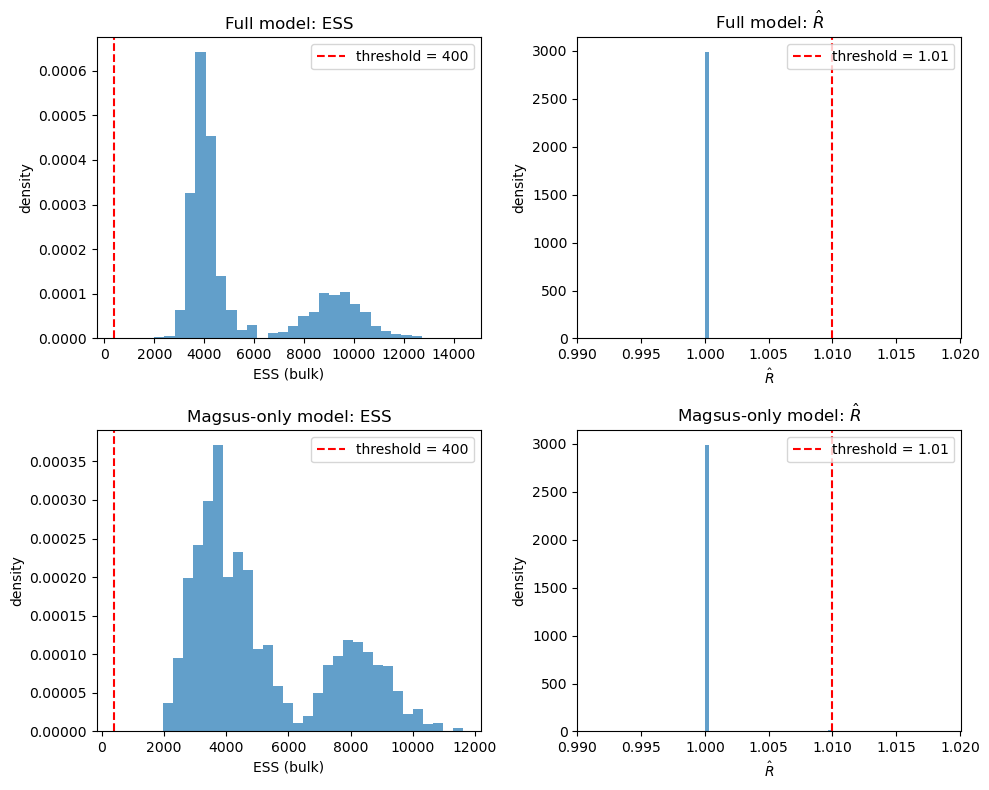

In [24]:

# --- call it ---
plot_rhat_ess_summaries(posterior_summary_full, 
                        posterior_summary_mag, 
                        outpath_prefix="../Output/mcmc_convergence_diagnostics_simulated")


In [25]:
def qbands_xr_depth_last(xarr):
    """
    Compute 5, 50, 95% quantiles over (chain, draw) for an xarray DataArray
    whose remaining dimension (e.g. depth or bin index) is the last axis.
    """
    depth_dim = [d for d in xarr.dims if d not in ("chain", "draw")][0]
    vals = xarr.transpose("chain", "draw", depth_dim).stack(s=("chain", "draw")).values
    # ensure shape (S, depth)
    if vals.shape[0] < vals.shape[1]:
        vals = vals.T
    return np.percentile(vals, [5, 50, 95], axis=0)


## Plot functions

In [26]:
def plot_posteriors(
    data_dict,
    idata,
    prefix_I="I_",
    prefix_mu="mu_w_",
    hyper_vars=None,
    sim_params=None,
    outpath_prefix="../Output/posteriors",
):
    """
    Plot, per trench:
      - I(d) posterior vs true latent I(d)
      - magsus posterior mean/ribbon (via regression on I(d)) vs magsus data
    Plus:
      - ceramic NB means vs counts
      - forest plot of hyperparameters
    """

    T            = data_dict["T"]
    Z_all        = data_dict["Z_all"]
    obs_idx_all  = data_dict["obs_idx_all"]
    y_reps_all   = data_dict["y_reps_all"]
    c_all        = data_dict["c_all"]
    edges_all    = data_dict["edges_all"]
    A_all        = data_dict["A_all"]
    I_true_all   = data_dict.get("I_true_all")   # may be None

    trench_ids = data_dict.get("trench_ids", list(range(T)))

    # convenience: magsus regression parameters
    a_mag_da = idata.posterior["a_mag_t"]      # dims: chain, draw, trench_dim
    b_mag_da = idata.posterior["b_mag_t"]

    # ---------------------------
    # 1) I(d) + magsus by trench
    # ---------------------------

    trenches_per_row = 2       # two trenches per row
    nrows = math.ceil(T / trenches_per_row)
    ncols = trenches_per_row * 2   # I(d) + magsus panels

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex="col",          # share x within each column
        sharey=False,
    )
    axes = np.atleast_2d(axes)

    # after: axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # trench dimension names for a_mag_t / b_mag_t
    trench_dim_a = [d for d in a_mag_da.dims if d not in ("chain", "draw")][0]
    trench_dim_b = [d for d in b_mag_da.dims if d not in ("chain", "draw")][0]

    for t in range(T):
        row      = t // trenches_per_row
        col_base = (t % trenches_per_row) * 2  # left panel index for this trench

        ax_I = axes[row, col_base]       # I(d)
        ax_M = axes[row, col_base + 1]   # magsus

        # ---------- Left panel: I(d) ----------
        Z_t    = Z_all[t][:, 0]
        I_da_t = idata.posterior[f"{prefix_I}{t}"]

        q5, q50, q95 = qbands_xr_depth_last(I_da_t)

        ax_I.fill_betweenx(Z_t, q5, q95, color="#7da9df", alpha=0.25, label="I 5–95%")
        ax_I.plot(q50, Z_t, color="#1f4e79", lw=2, label="I median")

        if I_true_all is not None:
            I_true_t = np.asarray(I_true_all[t], dtype=float)
            ax_I.plot(
                I_true_t,
                Z_t,
                "k--",
                lw=1.2,
                label="I true" if t == 0 else None,
            )

        ax_I.invert_yaxis()
        ax_I.set_title(
            f"Trench {trench_ids[t] + 1 if trench_ids == list(range(T)) else trench_ids[t]} - I(d)"
        )

        # y-axis label only handled globally later
        ax_I.set_ylabel("")

        # x-axis label only on bottom row
        if row == nrows - 1:
            ax_I.set_xlabel("I(d)")
        else:
            ax_I.set_xlabel("")

        # ---------- Right panel: magsus ----------
        obs_idx_t = np.asarray(obs_idx_all[t], dtype="int64")
        Z_obs_t   = Z_all[t][obs_idx_t, 0]

        for r in range(len(y_reps_all[t])):
            ax_M.scatter(
                y_reps_all[t][r],
                Z_obs_t,
                s=14,
                alpha=0.6,
                color="black",
                label="magsus data" if (t == 0 and r == 0) else None,
            )
            # magsus right-hand panels
            ax_M.set_ylabel("")
            ax_M.tick_params(labelleft=False)       # no labels
            ax_M.spines["left"].set_visible(False)  # hide left axis line as well
            ax_M.tick_params(axis="y", which="both", left=False, labelleft=False)
            
            # --- posterior predictive dashed bands for magsus ---
            if "posterior_predictive" in idata.groups() and f"y_obs_{t}" in idata.posterior_predictive:

                pp_y_da = idata.posterior_predictive[f"y_obs_{t}"]

                # collapse chain/draw/replicates -> samples axis `s`
                non_cd_dims = [d for d in pp_y_da.dims if d not in ("chain", "draw")]
                obs_dim = non_cd_dims[-1]

                pp_y_stack = pp_y_da.stack(s=("chain", "draw") + tuple(non_cd_dims[:-1]))
                pp_vals = pp_y_stack.transpose("s", obs_dim).values  # (S, n_obs)

                y5, y50_pred, y95 = np.percentile(pp_vals, [5, 50, 95], axis=0)

                ax_M.plot(
                    y5,
                    Z_obs_t,
                    linestyle="--",
                    color="#e4a419",
                    alpha=0.25,
                    linewidth=1,
                    label="magsus pred 5–95%" if t == 0 else None,
                )
                ax_M.plot(
                    y95,
                    Z_obs_t,
                    linestyle="--",
                    color="#e4a419",
                    alpha=0.25,
                    linewidth=1,
                )

        a_mag_t_da = a_mag_da.isel({trench_dim_a: t})
        b_mag_t_da = b_mag_da.isel({trench_dim_b: t})

        I_depth_dim = [d for d in I_da_t.dims if d not in ("chain", "draw")][0]
        I_obs_da    = I_da_t.isel({I_depth_dim: obs_idx_t})

        mu_y_da = a_mag_t_da + b_mag_t_da * I_obs_da

        mu5, mu50, mu95 = qbands_xr_depth_last(mu_y_da)

        ax_M.fill_betweenx(
            Z_obs_t,
            mu5,
            mu95,
            color="#e4a419",
            alpha=0.25,
            label="magsus μ 5–95%" if t == 0 else None,
        )
        ax_M.plot(
            mu50,
            Z_obs_t,
            color="#776e18",
            lw=2,
            label="magsus μ median" if t == 0 else None,
        )

        ax_M.invert_yaxis()
        ax_M.set_title(
            f"Trench {trench_ids[t] + 1 if trench_ids == list(range(T)) else trench_ids[t]} - magsus"
        )

        # remove left axis from right-hand panels
        ax_M.set_ylabel("")
        ax_M.tick_params(labelleft=False)

        # x-axis label only on bottom row
        if row == nrows - 1:
            ax_M.set_xlabel("magsus (std)")
        else:
            ax_M.set_xlabel("")

    # blank unused axes if T is odd
    total_trench_slots = nrows * trenches_per_row
    for empty_t in range(T, total_trench_slots):
        row = empty_t // trenches_per_row
        col_base = (empty_t % trenches_per_row) * 2
        axes[row, col_base].axis("off")
        axes[row, col_base + 1].axis("off")

    # shared y-axis label for the whole figure
    fig.text(0.01, 0.5, "depth (cm)", va="center", rotation="vertical")

    # legends as before
    # ===============================================
    # Unified legend for the entire I(d)+magsus figure
    # ===============================================

    legend_handles = []
    legend_labels  = []

    # grab unique labels from the first I(d) panel
    h_I, l_I = axes[0, 0].get_legend_handles_labels()
    # and first magsus panel
    h_M, l_M = axes[0, 1].get_legend_handles_labels()

    for h, l in zip(h_I + h_M, l_I + l_M):
        if l not in legend_labels:
            legend_labels.append(l)
            legend_handles.append(h)

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False
    )

    plt.tight_layout(rect=[0.03, 0.05, 1, 1])
    outpath = Path(f"{outpath_prefix}_magsus.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    # -----------------------------------
    # 2) Ceramics: binned I(d) + NB means by trench
    # -----------------------------------

    trenches_per_row_c = 2          # two trenches per row
    nrows_c = math.ceil(T / trenches_per_row_c)
    ncols_c = trenches_per_row_c * 2   # left: binned I(d), right: NB

    fig, axes = plt.subplots(
        nrows_c,
        ncols_c,
        figsize=(4 * ncols_c, 3 * nrows_c),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_2d(axes)

    # tidy spines
    for ax in axes.ravel():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for t in range(T):
        row      = t // trenches_per_row_c
        col_base = (t % trenches_per_row_c) * 2

        ax_Ib = axes[row, col_base]       # left: binned I(d)
        ax_NB = axes[row, col_base + 1]   # right: NB mean + counts

        # depth bins
        edges_t    = edges_all[t]
        bin_mids_t = 0.5 * (edges_t[:-1] + edges_t[1:])   # (B_t,)
        counts_t   = c_all[t]                             # (B_t,)
        A_t        = np.asarray(A_all[t], dtype=float)    # (B_t, D_t)

        # --------- LEFT: binned I(d) posterior vs true ----------
        # posterior samples for I(d)
        I_da_t   = idata.posterior[f"{prefix_I}{t}"]  # chain, draw, depth_dim
        depth_dim = [d for d in I_da_t.dims if d not in ("chain", "draw")][0]

        # stack chain & draw into a single dimension *first*,
        # then put that dimension first so we get (S, D_t)
        I_da_stack = I_da_t.stack(s=("chain", "draw"))          # dims: ('s', depth_dim)
        I_vals     = I_da_stack.transpose("s", depth_dim).values  # shape: (S, D_t)

        # binned I(d) for each posterior sample: (S, B_t)
        I_binned_samples = I_vals @ A_t.T                       # (S, D_t) @ (D_t, B_t) -> (S, B_t)

        # quantiles over samples axis -> (B_t,)
        I_b5, I_b50, I_b95 = np.percentile(I_binned_samples, [5, 50, 95], axis=0)

        # ribbon + median for binned I(d)
        ax_Ib.fill_betweenx(
            bin_mids_t,
            I_b5,
            I_b95,
            color="#aec7e8",
            alpha=0.35,
            label="binned I(d) 5–95%" if t == 0 else None,
        )
        ax_Ib.plot(
            I_b50,
            bin_mids_t,
            color="#1f77b4",
            lw=2,
            label="binned I(d) median" if t == 0 else None,
        )

        # true binned I(d)
        if I_true_all is not None:
            I_true_t  = np.asarray(I_true_all[t], dtype=float)   # (D_t,)
            zbar_true = A_t @ I_true_t                           # (B_t,)
            ax_Ib.plot(
                zbar_true,
                bin_mids_t,
                "k--",
                lw=1.2,
                label="binned I(d) true" if t == 0 else None,
            )

        ax_Ib.invert_yaxis()
        ax_Ib.set_title(
            f"Trench {trench_ids[t] + 1 if trench_ids == list(range(T)) else trench_ids[t]} - I(d) binned"
        )

        ax_NB.tick_params(axis="x", labelbottom=True)

        # x labels only bottom row
        if row == nrows_c - 1:
            ax_Ib.set_xlabel("binned I(d)")
        else:
            ax_Ib.set_xlabel("")
            #ax_Ib.tick_params(axis="x", labelbottom=False)

        # y labels handled globally
        ax_Ib.set_ylabel("")

        # --------- RIGHT: NB mean ribbon + counts ----------
        mu_da = idata.posterior[f"{prefix_mu}{t}"]  # (chain, draw, bin_dim)
        mu5, mu50, mu95 = qbands_xr_depth_last(mu_da)

        ax_NB.fill_betweenx(
            bin_mids_t,
            mu5,
            mu95,
            color="#ffbb78",
            alpha=0.35,
            label="E[count] 5–95%" if t == 0 else None,
        )
        ax_NB.plot(
            mu50,
            bin_mids_t,
            color="#ff7f0e",
            lw=2,
            label="E[count] median" if t == 0 else None,
        )
        ax_NB.scatter(
            counts_t,
            bin_mids_t,
            s=14,
            alpha=0.9,
            color="black",
            label="counts" if t == 0 else None,
        )

        ax_NB.invert_yaxis()
        ax_NB.set_title(
            f"Trench {trench_ids[t] + 1 if trench_ids == list(range(T)) else trench_ids[t]} - ceramics"
        )

        # remove y axis on right-hand panels (to visually pair with left)
        ax_NB.set_ylabel("")
        ax_NB.spines["left"].set_visible(False)
        ax_NB.tick_params(axis="y", left=False, labelleft=False)

        # --- posterior predictive dashed bands for ceramic counts ---
        if "posterior_predictive" in idata.groups() and f"c_obs_{t}" in idata.posterior_predictive:

            pp_c_da = idata.posterior_predictive[f"c_obs_{t}"]

            c5, c50_pred, c95 = qbands_xr_depth_last(pp_c_da)

            ax_NB.plot(
                c5,
                bin_mids_t,
                linestyle="--",
                color="#ffbb78",
                alpha=0.75,
                linewidth=1,
                label="count pred 5–95%" if t == 0 else None,
            )
            ax_NB.plot(
                c95,
                bin_mids_t,
                linestyle="--",
                color="#ffbb78",
                alpha=0.75,
                linewidth=1,
            )

        ax_NB.tick_params(axis="x", labelbottom=True)

        # x labels only bottom row
        if row == nrows_c - 1:
            ax_NB.set_xlabel("ceramic count")
        else:
            ax_NB.set_xlabel("")
            #ax_NB.tick_params(axis="x", labelbottom=False)

    # blank any unused axes if T is odd
    total_trench_slots_c = nrows_c * trenches_per_row_c
    for empty_t in range(T, total_trench_slots_c):
        row = empty_t // trenches_per_row_c
        col_base = (empty_t % trenches_per_row_c) * 2
        axes[row, col_base].axis("off")
        axes[row, col_base + 1].axis("off")

    # shared y-axis label
    fig.text(0.01, 0.5, "depth (cm)", va="center", rotation="vertical")

    # unified legend from first trench's panels
    h_Ib, l_Ib = axes[0, 0].get_legend_handles_labels()
    h_NB, l_NB = axes[0, 1].get_legend_handles_labels()

    legend_handles = []
    legend_labels  = []
    for h, l in zip(h_Ib + h_NB, l_Ib + l_NB):
        if l not in legend_labels and l != "":
            legend_labels.append(l)
            legend_handles.append(h)

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=min(3, len(legend_labels)),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0.03, 0.05, 1, 1])
    outpath = Path(f"{outpath_prefix}_ceramics.png")
    plt.savefig(outpath, bbox_inches="tight")

    plt.show()


    # -----------------------------------
    # 3) Hyperparameter forest plot
    # -----------------------------------
    if hyper_vars is None:
        hyper_vars = ["b_t", "b_mag_t"]
    if sim_params is not None:
        forest_with_truth(idata_full_simulated, {k: sim_params[k] for k in hyper_vars})


def forest_with_truth(idata, 
                      sim_params, 
                      hdi_prob=0.94):
    for name, true_vals in sim_params.items():
        if name not in idata.posterior:
            print(f"Skipping {name}: not in posterior")
            continue

        true_vals = np.asarray(true_vals)
        n = true_vals.size

        az.plot_forest(
            idata,
            var_names=[name],
            combined=False,
            hdi_prob=hdi_prob,
            figsize=(8, 1.5 + 0.4 * n),  # more vertical room per parameter
        )
        ax = plt.gca()

        ylocs = ax.get_yticks()
        if len(ylocs) == n:
            # if order looks inverted, just use true_vals[::-1] instead
            ax.scatter(true_vals, ylocs, marker="x", color="k", zorder=5, label="true")

        if "true" in ax.get_legend_handles_labels()[1]:
            ax.legend(loc="lower right")

        ax.set_title(f"{name} (posterior HDI + true)")
        plt.tight_layout()
        #outpath = Path(f"{outpath_prefix}_params.png")
        #plt.savefig(outpath, bbox_inches="tight")

        plt.show()

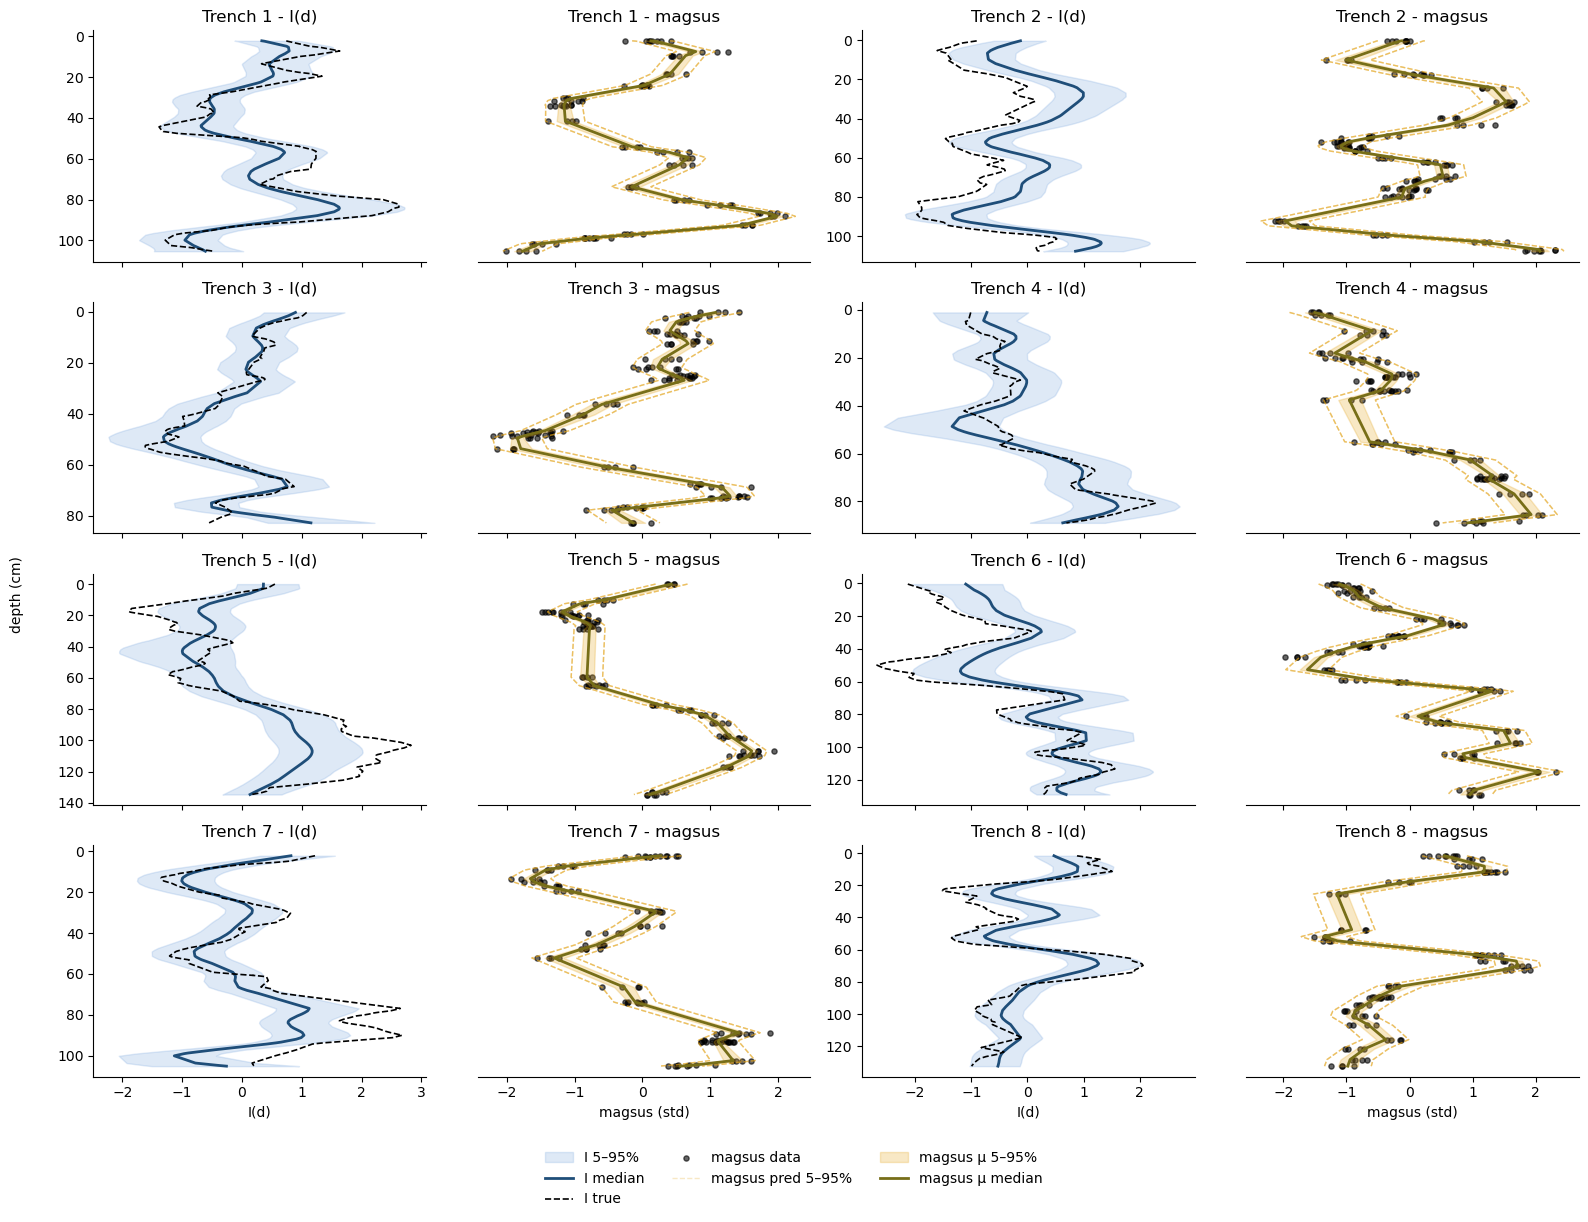

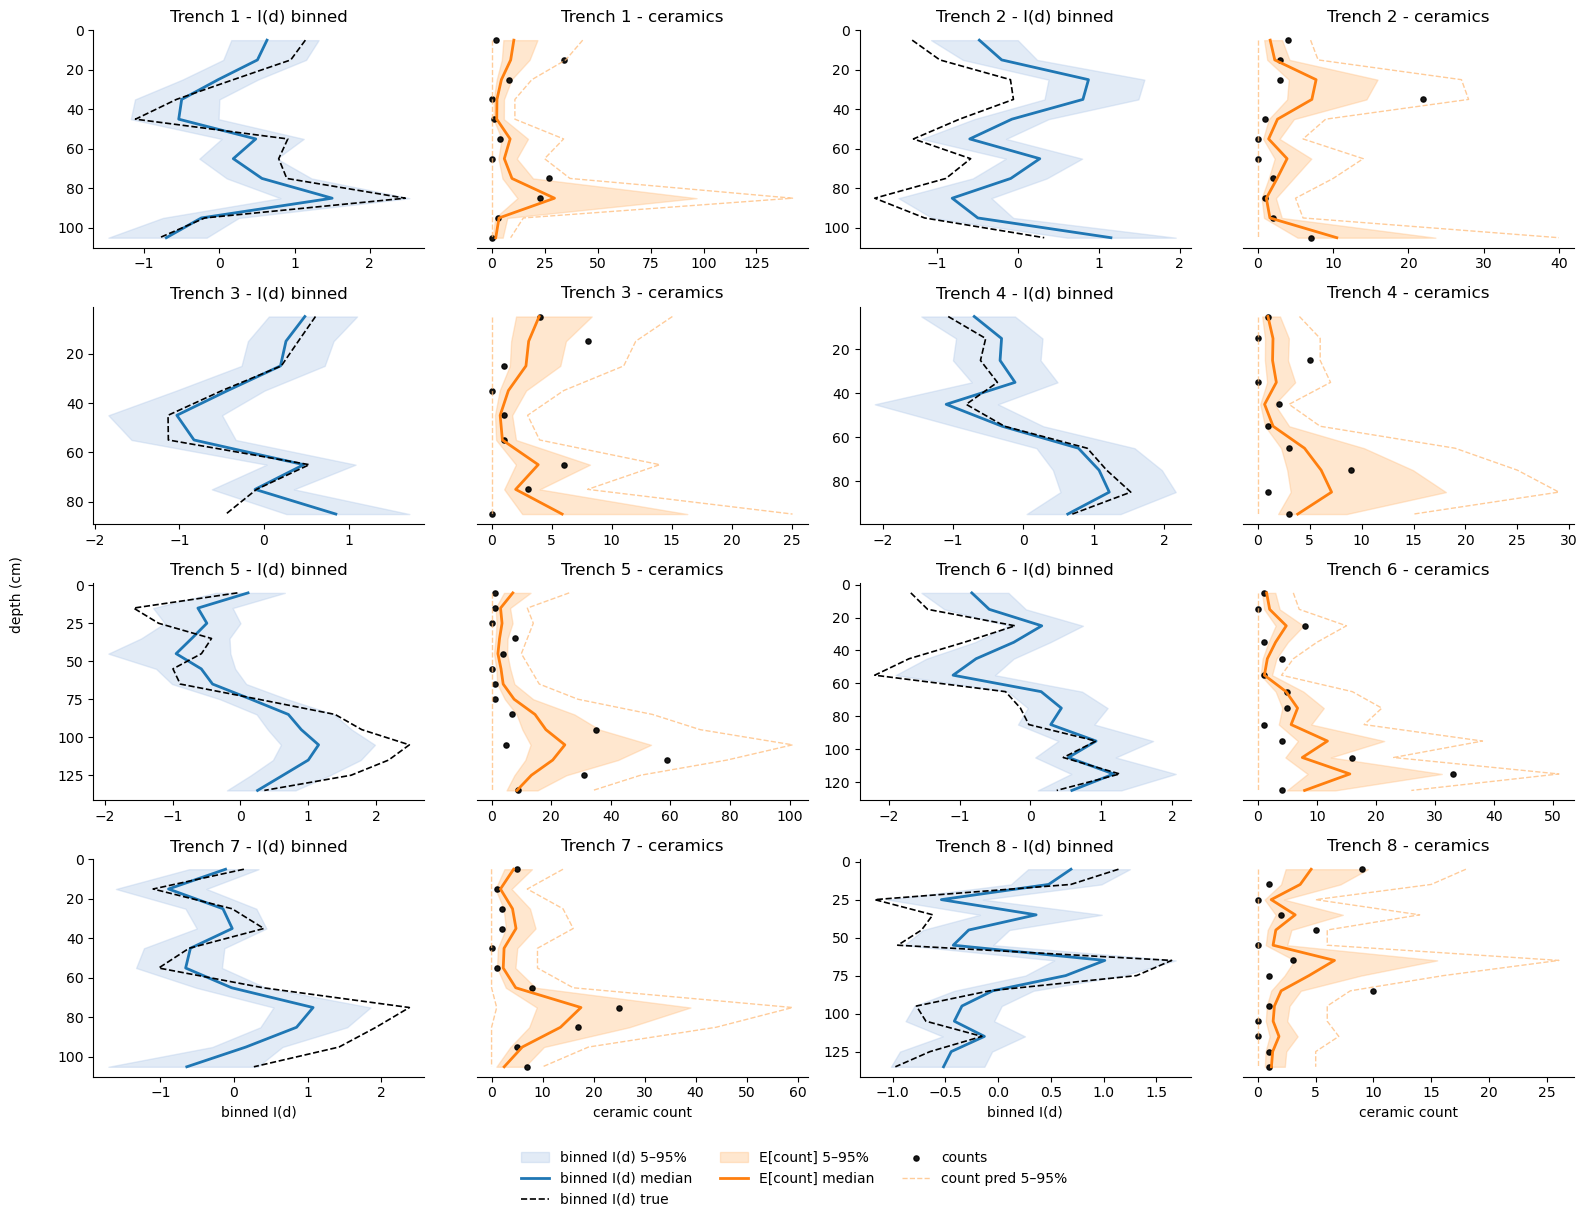

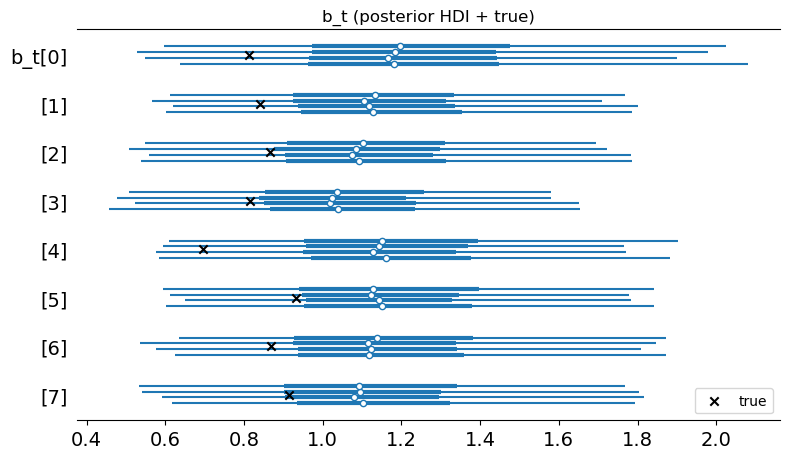

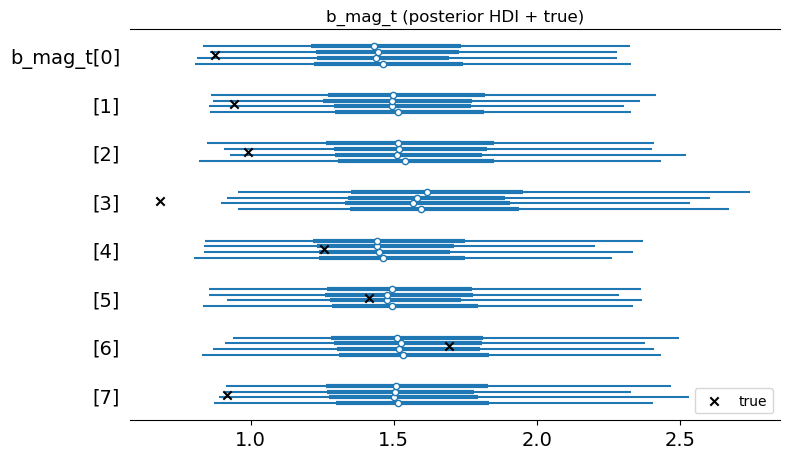

In [27]:
plot_posteriors(simdata, idata_full_simulated, sim_params=sim_params, outpath_prefix="../Output/posteriors_simulated")

In [28]:
def qbands_ppc(arr, q=(5, 50, 95)):
    """
    arr: posterior predictive array with leading dims (chain, draw, ...)
         We flatten (chain, draw) and take percentiles over that axis.
    Returns: array of shape (len(q), ...) with quantiles.
    """
    a = np.asarray(arr)
    # flatten chain, draw into single sample dimension
    s = a.reshape(a.shape[0] * a.shape[1], *a.shape[2:])
    return np.percentile(s, q, axis=0)

def coverage(observed, q_low, q_high):
    """
    Proportion of observed values lying within [q_low, q_high].
    Shapes must be broadcast-compatible.
    """
    obs = np.asarray(observed)
    return np.mean((obs >= q_low) & (obs <= q_high))


def plot_ppc(
    data_dict,
    idata,
    use_ceramics: bool = True,
    y_prefix: str = "y_obs_",
    c_prefix: str = "c_obs_",
):
    """
    Plot posterior predictive checks for magsus (and optionally ceramics).

    Parameters
    ----------
    data_dict : dict
        Expected keys:
            - "T": int
            - "Z_all": list of length T, each (D_t, 1)
            - "obs_idx_all": list of length T, each (n_obs_t,) int
            - "y_reps_all": list of length T, each list of R_t arrays (n_obs_t,)
        If use_ceramics:
            - "c_all": list of length T, each (B_t,)
            - "edges_all": list of length T, each (B_t+1,)
    idata : arviz.InferenceData
        Must contain a posterior_predictive group with variables:
            y_prefix + f"{t}"   for magsus PPC
            c_prefix + f"{t}"   for ceramics PPC (if use_ceramics)
    use_ceramics : bool
        Whether to also plot ceramic PPC.
    y_prefix, c_prefix : str
        Name prefixes used when defining the likelihoods in the model.
    """

    T           = data_dict["T"]
    Z_all       = data_dict["Z_all"]
    obs_idx_all = data_dict["obs_idx_all"]
    y_reps_all  = data_dict["y_reps_all"]

    # --------------------------------
    # 1) Magsus PPC plots + coverage
    # --------------------------------
    ncols = min(4, T)
    nrows = math.ceil(T / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    magsus_coverages = []

    for t, ax in enumerate(axes.flat):
        if t >= T:
            ax.axis("off")
            continue

        # observed magsus: (R_t, n_obs_t)
        Y_obs = np.vstack(y_reps_all[t])
        dep   = Z_all[t][obs_idx_all[t], 0]  # (n_obs_t,)

        # ppc: (chain, draw, R_t, n_obs_t)
        y_ppc = idata.posterior_predictive[f"{y_prefix}{t}"].values
        y5, y50, y95 = qbands_ppc(y_ppc)  # each (R_t, n_obs_t)

        jitter = np.linspace(-0.12, 0.12, Y_obs.shape[0])
        for r in range(Y_obs.shape[0]):
            ax.fill_betweenx(dep + jitter[r], y5[r], y95[r], alpha=0.2)
            ax.plot(y50[r], dep + jitter[r], lw=2)
            ax.scatter(Y_obs[r], dep + jitter[r], s=10, alpha=0.8)

        ax.invert_yaxis()
        ax.set_title(f"Trench {t+1}")
        if t % ncols == 0:
            ax.set_ylabel("depth (cm)")
        if t >= (nrows-1)*ncols:
            ax.set_xlabel("magsus")

        # numeric coverage for this trench
        cov_t = coverage(Y_obs, y5, y95)
        magsus_coverages.append(cov_t)

    plt.tight_layout()
    plt.show()

    # print magsus coverage
    for t, cov_t in enumerate(magsus_coverages):
        print(f"Magsus 90% coverage — Trench {t+1}: {cov_t:.3f}")

    # --------------------------------
    # 2) Ceramics PPC plots + coverage
    # --------------------------------
    if use_ceramics:
        c_all      = data_dict["c_all"]
        edges_all  = data_dict["edges_all"]
        bin_mids_all = [0.5*(e[:-1] + e[1:]) for e in edges_all]

        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=True)
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        ceramics_coverages = []

        for t, ax in enumerate(axes.flat):
            if t >= T:
                ax.axis("off")
                continue

            c_obs = np.asarray(c_all[t])  # (B_t,)
            c_ppc = idata.posterior_predictive[f"{c_prefix}{t}"].values  # (chain, draw, B_t)
            c5, c50, c95 = qbands_ppc(c_ppc)  # each (B_t,)

            ax.fill_betweenx(bin_mids_all[t], c5, c95, alpha=0.25, label="pred 5–95%")
            ax.plot(c50, bin_mids_all[t], lw=2, label="pred median")
            ax.scatter(c_obs, bin_mids_all[t], s=14, alpha=0.9, label="observed")

            ax.invert_yaxis()
            ax.set_title(f"Trench {t+1}")
            if t % ncols == 0:
                ax.set_ylabel("depth (cm)")
            if t >= (nrows-1)*ncols:
                ax.set_xlabel("ceramic count")

            cov_t = coverage(c_obs, c5, c95)
            ceramics_coverages.append(cov_t)

        plt.tight_layout()
        plt.show()

        for t, cov_t in enumerate(ceramics_coverages):
            print(f"Ceramics 90% coverage — Trench {t+1}: {cov_t:.3f}")


In [29]:
def stack_samples_depth_last(xarr):
    depth_dim = [d for d in xarr.dims if d not in ("chain","draw")][0]
    vals = xarr.transpose("chain","draw",depth_dim).stack(s=("chain","draw")).values
    if vals.shape[0] < vals.shape[1]:
        vals = vals.T
    return np.asarray(vals)  # (S, D)

def qbands(arr, q=(5,50,95)):
    return np.percentile(np.asarray(arr), q, axis=0)

In [30]:
def plot_delta_I(
    idata_full,
    idata_magsus_only,
    data_dict,
    var_prefix: str = "I_",
    outpath_prefix: str = "../Output/delta_I",
):
    """
    Compare I(d) between the full model and the magsus-only model and plot ΔI.

    Parameters
    ----------
    idata_full : arviz.InferenceData
        InferenceData for the full model (with ceramics).
    idata_magsus_only : arviz.InferenceData
        InferenceData for the magsus-only model.
    data_dict : dict
        Must contain:
            - "T"     : int, number of trenches
            - "Z_all" : list of length T, each array (D_t, 1) giving depth grid
    var_prefix : str
        Prefix used for I(d) variables in the posterior (default "I_").

    Returns
    -------
    fraction_zero_cover : list of float
        For each trench t, the fraction of depths where 0 lies in the 5–95% band
        of ΔI(d).
    """

    T      = data_dict["T"]
    Z_all  = data_dict["Z_all"]

    ncols = min(4, T)
    nrows = math.ceil(T / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=False)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    fraction_zero_cover = []

    for t, ax in enumerate(axes.flat):
        if t >= T:
            ax.axis("off")
            continue

        # samples of I(d) from both fits, shapes: (S_full, D_t), (S_only, D_t)
        I_full = stack_samples_depth_last(idata_full.posterior[f"{var_prefix}{t}"])
        I_only = stack_samples_depth_last(idata_magsus_only.posterior[f"{var_prefix}{t}"])

        # pair same number of draws (first S; you can randomize if you like)
        S = min(I_full.shape[0], I_only.shape[0])
        I_full_s = I_full[:S]
        I_only_s = I_only[:S]

        # difference distribution
        dI = I_full_s - I_only_s  # (S, D_t)

        d5, d50, d95 = qbands(dI, q=(5, 50, 95))
        depth_vals = Z_all[t][:, 0]

        ax.axvline(0, color="k", lw=1, alpha=0.4)
        ax.fill_betweenx(depth_vals, d5, d95, alpha=0.25, label="ΔI 5–95%")
        ax.plot(d50, depth_vals, lw=2, label="ΔI median")
        ax.invert_yaxis()
        ax.set_title(f"Trench {t+1}")
        ax.set_xlabel("ΔI(d) = I_full − I_magsus")
        ax.set_ylabel("depth (cm)")

        # fraction of depths where 0 ∈ [5,95]
        zero_in = (d5 <= 0) & (0 <= d95)
        fraction_zero_cover.append(float(np.mean(zero_in)))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=2)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    outpath = Path(f"{outpath_prefix}.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    for t, frac in enumerate(fraction_zero_cover, 1):
        print(f"Trench {t}: fraction depths with 0 in 5–95% band = {frac:.3f}")

    return fraction_zero_cover


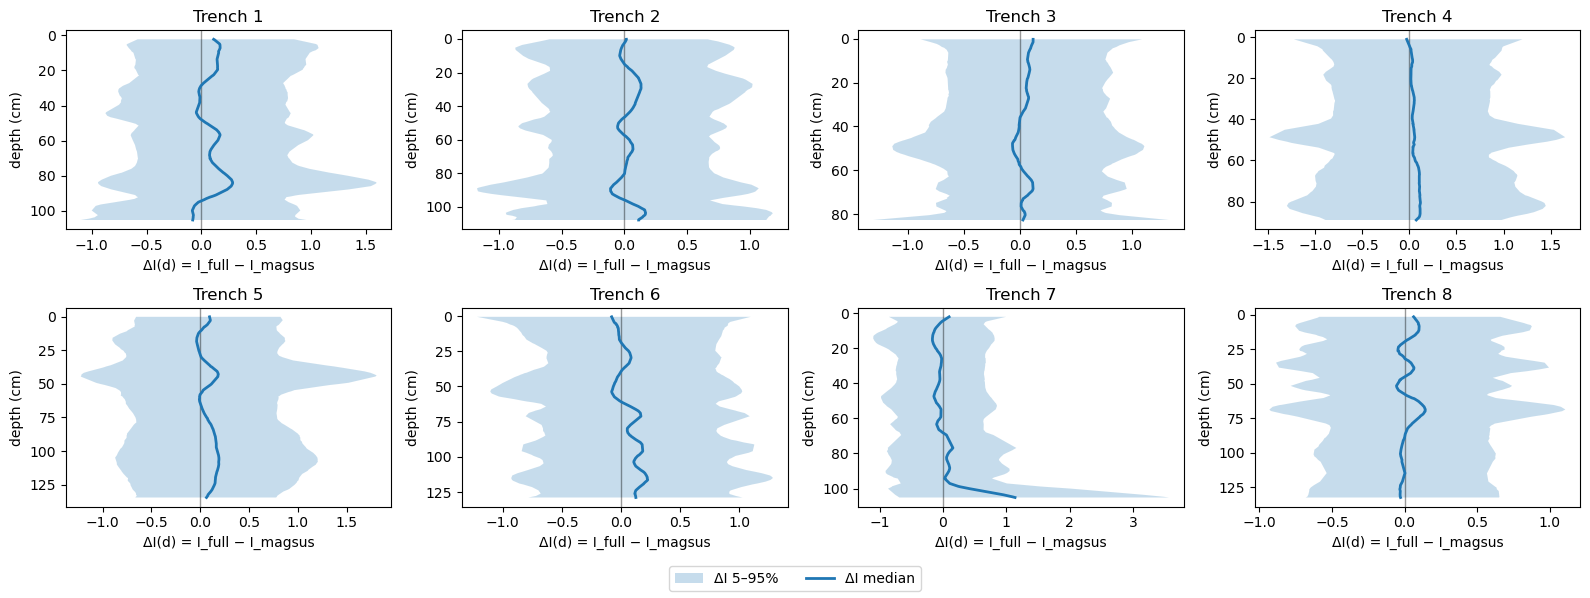

Trench 1: fraction depths with 0 in 5–95% band = 1.000
Trench 2: fraction depths with 0 in 5–95% band = 1.000
Trench 3: fraction depths with 0 in 5–95% band = 1.000
Trench 4: fraction depths with 0 in 5–95% band = 1.000
Trench 5: fraction depths with 0 in 5–95% band = 1.000
Trench 6: fraction depths with 0 in 5–95% band = 1.000
Trench 7: fraction depths with 0 in 5–95% band = 1.000
Trench 8: fraction depths with 0 in 5–95% band = 1.000


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [31]:
plot_delta_I(
    idata_full_simulated,
    idata_magsus_simulated,
    simdata,
    outpath_prefix="../Output/delta_I_simulated",
)

## Koh Ker Data
Below we run the same model but using the actual data from Koh Ker. We follow these steps:

1. Prepare the data, including interpolation of magsus readings onto trench-specific depth grids
2. Fit the model
3. Compare the latent human influence processes inferred from magsus alone vs. both magsus and artifact counts
4. Visualize and interpret the results

In [32]:
# prep magsus data for ragged HSGP model fitting

# magsus: columns ["record_id", "trench_id", "scan_idx", "susceptibility", "depth"]

magsus_df = magsus.copy()

# choose depth step for resampling (cm)
depth_step = 1.0   # you can change to 0.5, 2.0, etc.

trench_ids = np.sort(magsus_df["trench_id"].unique())
T = len(trench_ids)

Z_all       = []   # per-trench depth grid (D_t, 1)
y_reps_all  = []   # per-trench list of scan arrays, each (D_t,)
obs_idx_all = []   # per-trench array of indices into Z_t (here: all depths)


for trench in trench_ids:
    df_t = magsus_df[magsus_df["trench_id"] == trench].copy()
    scan_ids = np.sort(df_t["scan_idx"].unique())

    # enforce consistent number of replicates
    if len(scan_ids) > 4:
        scan_ids = scan_ids[:4]   # keep first 4 scans

for trench in trench_ids:
    df_t = magsus_df[magsus_df["trench_id"] == trench].copy()
    scan_ids = np.sort(df_t["record_id"].unique())

    # enforce consistent number of replicates
    if len(scan_ids) > 4:
        scan_ids = scan_ids[:4]   # keep first 4 scans

    # depth range for this trench
    min_depth = df_t["depth"].astype(float).min()
    max_depth = df_t["depth"].astype(float).max()

    # define regular grid from surface to bottom
    grid = np.arange(min_depth, max_depth + depth_step * 0.5, depth_step)
    Z_t = grid[:, None]          # shape (D_t, 1)
    Z_all.append(Z_t)

    D_t = grid.size
    obs_idx_all.append(np.arange(D_t, dtype=int))  # we now have a value at every grid depth

    # interpolate each scan onto this grid
    y_reps_t = []

    for scan in scan_ids:
        df_s = df_t[df_t["record_id"] == scan].copy()
        df_s.sort_values("depth", inplace=True)

        d_s = df_s["depth"].astype(float).values
        y_s = df_s["susceptibility"].astype(float).values

        # interpolate susceptibility onto the regular grid
        # values outside [d_s.min, d_s.max] will use edge values by default;
        # since scans should go from surface to bottom, that’s fine.
        y_interp = np.interp(grid, d_s, y_s)

        # mean-center
        y_interp = (y_interp - y_interp.mean()) / y_interp.std()

        y_reps_t.append(y_interp)

    y_reps_all.append(y_reps_t)

# quick checks
print("Number of trenches (T):", T)
print("Depth grids (D_t):", [Z.shape[0] for Z in Z_all])
print("Obs_idx lengths:", [len(idx) for idx in obs_idx_all])
print("Replicate counts per trench:", [len(reps) for reps in y_reps_all])


Number of trenches (T): 8
Depth grids (D_t): [111, 91, 111, 101, 81, 141, 111, 101]
Obs_idx lengths: [111, 91, 111, 101, 81, 141, 111, 101]
Replicate counts per trench: [4, 4, 4, 4, 4, 4, 4, 4]


In [33]:
A_all = []
c_all = []
edges_all = []

trench_ids = sorted(ceramic_df["trench_id"].unique())

for t, tid in enumerate(trench_ids):
    # depth grid for this trench (from magsus prep)
    Z_t = Z_all[t][:, 0]  # flatten (D_t,)
    D_t = Z_t.shape[0]

    # ceramic rows for this trench, sorted by depth
    df_t = (
        ceramic_df
        .loc[ceramic_df["trench_id"] == tid]
        .dropna(subset=["depth_top_cm", "depth_bot_cm"])
        .sort_values("depth_mid_cm")
        .reset_index(drop=True)
    )

    B_t = len(df_t)  # number of ceramic bins
    c_t = df_t["ceramic_total_count"].to_numpy()
    c_all.append(c_t)

    # --- build edges_t (B_t+1,) from top/bottom depths ---
    # assume bins are contiguous and non-overlapping after sort
    edges_t = np.empty(B_t + 1, dtype=float)
    edges_t[:-1] = df_t["depth_top_cm"].to_numpy()
    edges_t[-1]  = df_t["depth_bot_cm"].to_numpy()[-1]
    edges_all.append(edges_t)

    # --- build A_t (B_t x D_t): average I(d) over each ceramic bin ---
    A_t = np.zeros((B_t, D_t))
    for j, (lo, hi) in enumerate(zip(df_t["depth_top_cm"], df_t["depth_bot_cm"])):
        if j < B_t - 1:
            mask = (Z_t >= lo) & (Z_t < hi)
        else:
            mask = (Z_t >= lo) & (Z_t <= hi)

        idx = np.where(mask)[0]
        if idx.size == 0:
            # fallback: nearest depth gets full weight
            k = np.argmin(np.abs(Z_t - (lo + hi) / 2.0))
            A_t[j, k] = 1.0
        else:
            A_t[j, idx] = 1.0 / idx.size

    A_all.append(A_t)

# quick sanity
print("Ceramic rows per trench:", [len(c) for c in c_all])
print("A_t shapes:", [A.shape for A in A_all])
print("Edges lengths:", [len(e) for e in edges_all])


Ceramic rows per trench: [13, 11, 11, 10, 9, 13, 12, 11]
A_t shapes: [(13, 111), (11, 91), (11, 111), (10, 101), (9, 81), (13, 141), (12, 111), (11, 101)]
Edges lengths: [14, 12, 12, 11, 10, 14, 13, 12]


In [34]:
# Bottle the KKPP24 data
kkpp24data = dict(
    T = len(Z_all),
    trench_ids = trench_ids,

    Z_all = Z_all,
    D_all = [Z.shape[0] for Z in Z_all],

    obs_idx_all = obs_idx_all,
    y_reps_all = y_reps_all,
    n_reps_all = [len(rep_list) for rep_list in y_reps_all],

    c_all = c_all,
    A_all = A_all,
    edges_all = edges_all,
    B_all = [len(c) for c in c_all],
)

In [35]:
idata_full_kkpp24   = run_hsgp(kkpp24data, use_ceramics=True, seed=seed, chains=nchains)
idata_magsus_kkpp24 = run_hsgp(kkpp24data, use_ceramics=False, seed=seed, chains=nchains)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ell_t, eta_t, sigma_y_t, a_mag_t, log_b_mag_mu, log_b_mag_sigma, eps_log_b_mag_t, a_t, log_b_mu, log_b_sigma, eps_log_b_t, phi_t, I_0_hsgp_coeffs, I_1_hsgp_coeffs, I_2_hsgp_coeffs, I_3_hsgp_coeffs, I_4_hsgp_coeffs, I_5_hsgp_coeffs, I_6_hsgp_coeffs, I_7_hsgp_coeffs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 389 seconds.
Sampling: [c_obs_0, c_obs_1, c_obs_2, c_obs_3, c_obs_4, c_obs_5, c_obs_6, c_obs_7, y_obs_0, y_obs_1, y_obs_2, y_obs_3, y_obs_4, y_obs_5, y_obs_6, y_obs_7]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ell_t, eta_t, sigma_y_t, a_mag_t, log_b_mag_mu, log_b_mag_sigma, eps_log_b_mag_t, I_0_hsgp_coeffs, I_1_hsgp_coeffs, I_2_hsgp_coeffs, I_3_hsgp_coeffs, I_4_hsgp_coeffs, I_5_hsgp_coeffs, I_6_hsgp_coeffs, I_7_hsgp_coeffs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 282 seconds.
Sampling: [y_obs_0, y_obs_1, y_obs_2, y_obs_3, y_obs_4, y_obs_5, y_obs_6, y_obs_7]


Output()

In [36]:
# --- get summaries (keep them in separate variables) ---
posterior_summary_full = az.summary(idata_full_kkpp24)
posterior_summary_mag  = az.summary(idata_magsus_kkpp24)

# optional: also keep CSVs on disk
posterior_summary_full.to_csv("../Output/posterior_summary_kkpp24_full.csv")
posterior_summary_mag.to_csv("../Output/posterior_summary_kkpp24_mag.csv")

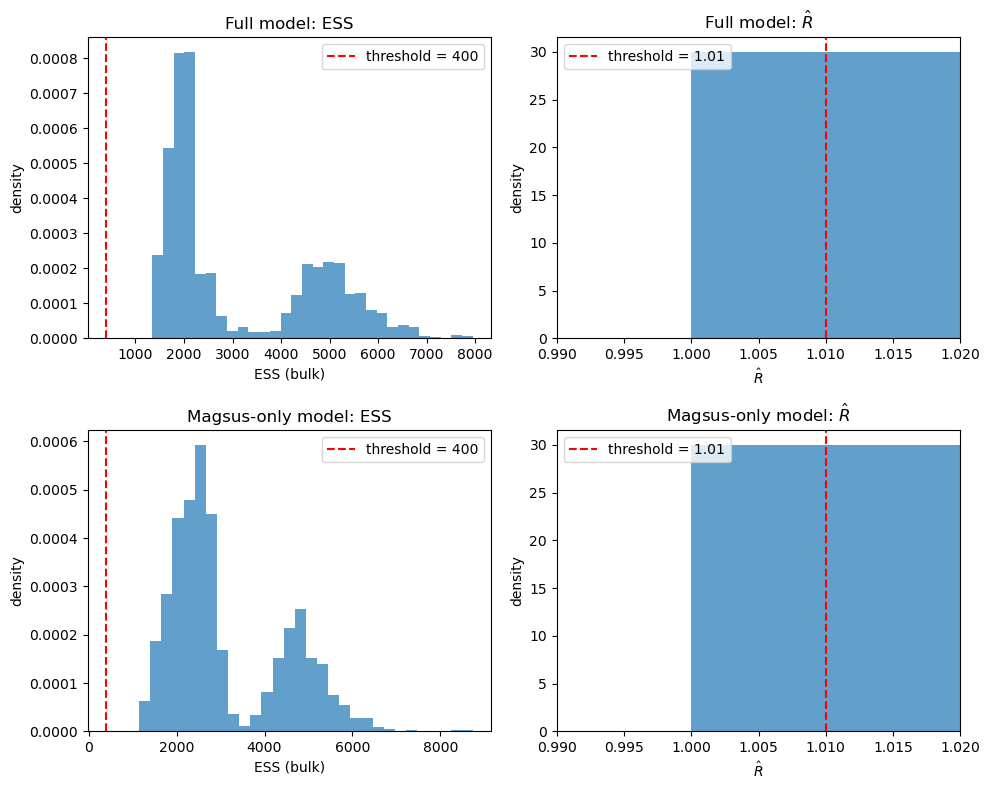

In [37]:
plot_rhat_ess_summaries(posterior_summary_full, 
                        posterior_summary_mag, 
                        outpath_prefix="../Output/mcmc_convergence_diagnostics_kkpp24")

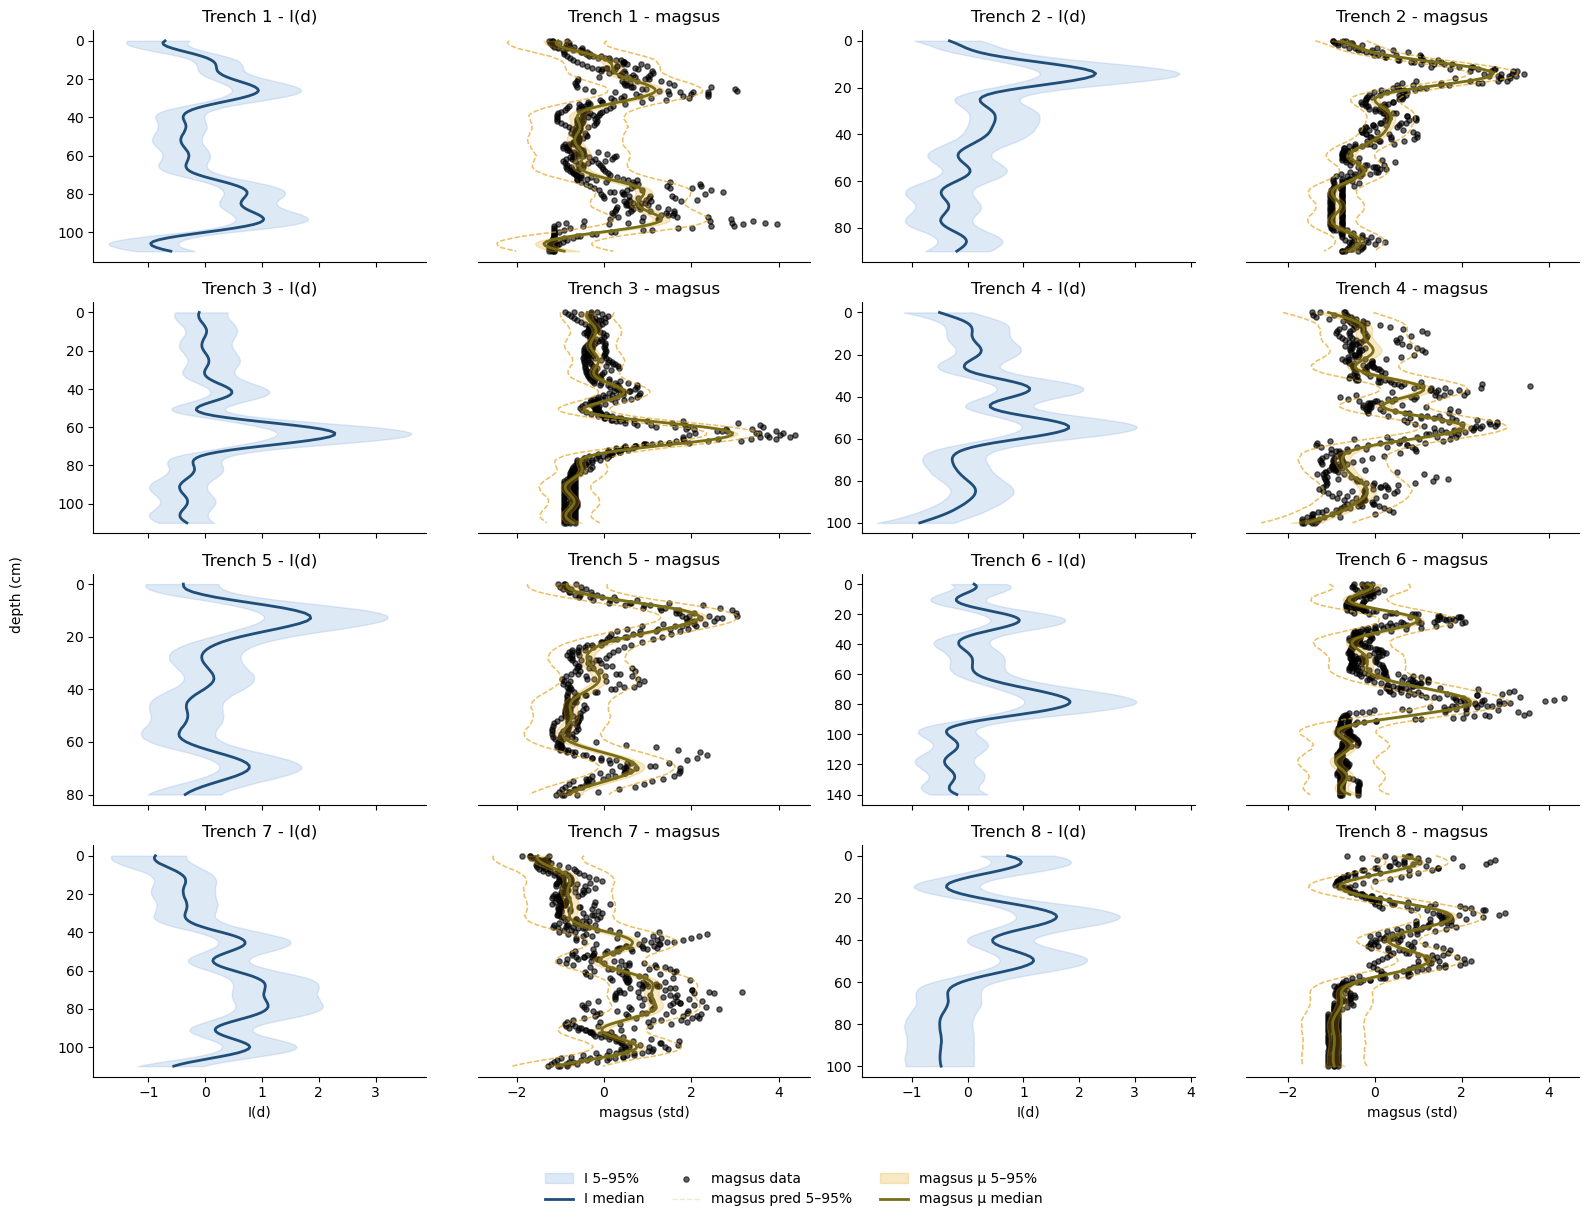

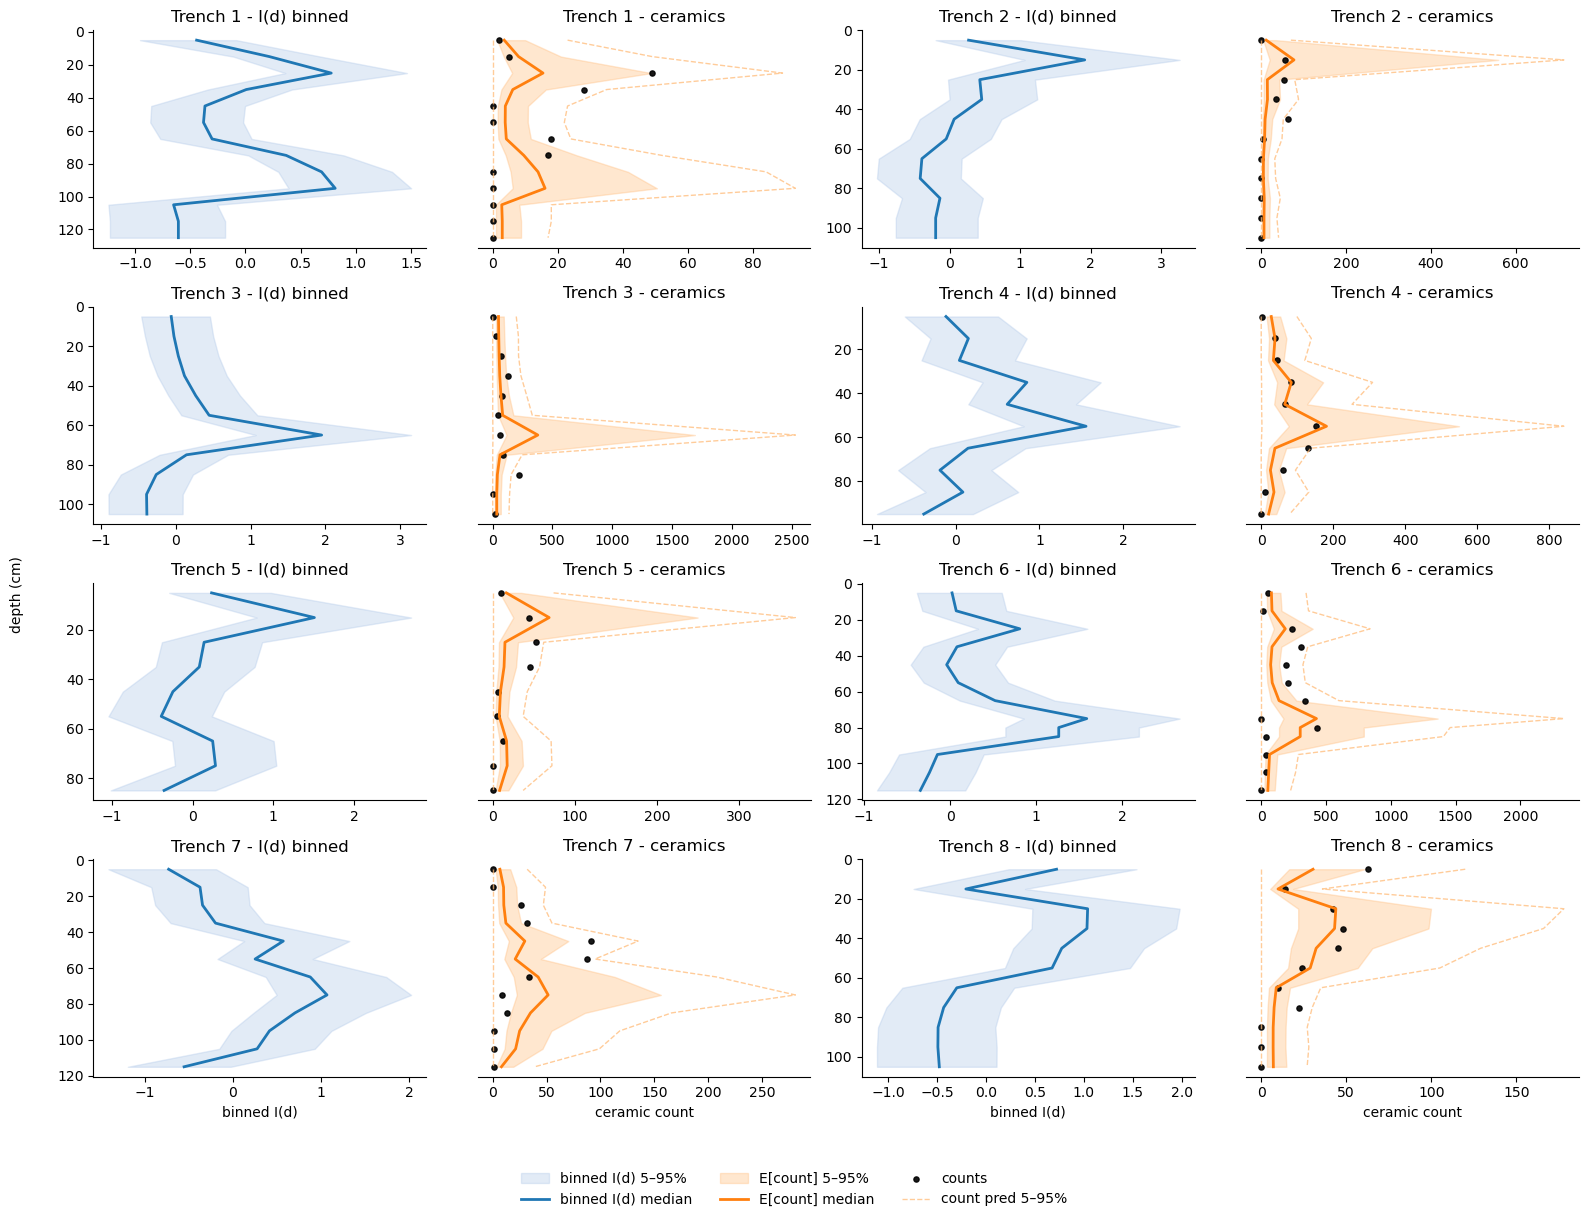

In [38]:
plot_posteriors(kkpp24data, idata_full_kkpp24, outpath_prefix="../Output/posteriors_kkpp24")

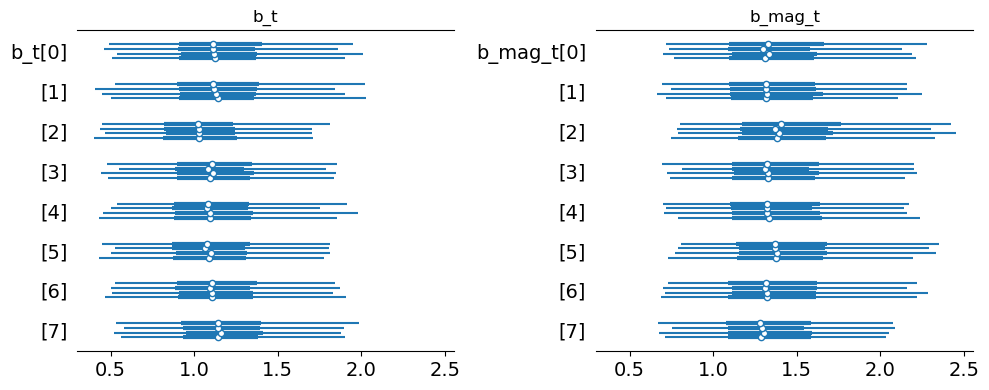

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

az.plot_forest(
    idata_full_kkpp24,
    var_names=["b_t"],
    combined=False,
    hdi_prob=0.94,
    ax=axes[0]
)
axes[0].set_title("b_t")

az.plot_forest(
    idata_full_kkpp24,
    var_names=["b_mag_t"],
    combined=False,
    hdi_prob=0.94,
    ax=axes[1]
)
axes[1].set_title("b_mag_t")

fig.tight_layout()
plt.savefig("../Output/forest_kkpp24.pdf", bbox_inches="tight")
plt.savefig("../Output/forest_kkpp24.png", bbox_inches="tight")

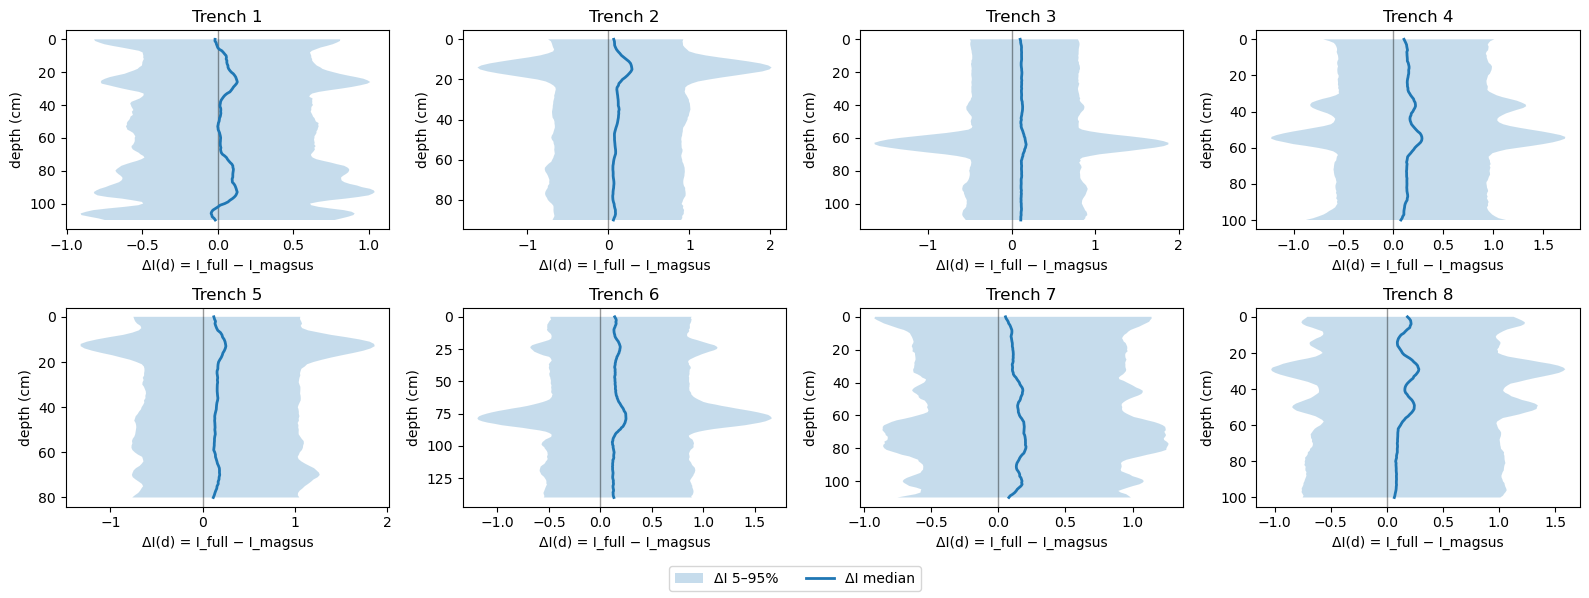

Trench 1: fraction depths with 0 in 5–95% band = 1.000
Trench 2: fraction depths with 0 in 5–95% band = 1.000
Trench 3: fraction depths with 0 in 5–95% band = 1.000
Trench 4: fraction depths with 0 in 5–95% band = 1.000
Trench 5: fraction depths with 0 in 5–95% band = 1.000
Trench 6: fraction depths with 0 in 5–95% band = 1.000
Trench 7: fraction depths with 0 in 5–95% band = 1.000
Trench 8: fraction depths with 0 in 5–95% band = 1.000


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [40]:
plot_delta_I(
    idata_full_kkpp24,
    idata_magsus_kkpp24,
    kkpp24data,
    outpath_prefix="../Output/delta_I_kkpp24",
)